# Đồ Án Machine Learning — Predict Delivery Time
## Mô tả bài toán
**Olist** là nền tảng thương mại điện tử lớn nhất tại Brazil. Mạng lưới hậu cần (logistics) của Brazil rất phức tạp do vị trí địa lý rộng lớn và cơ sở hạ tầng phân tán. Điều này dẫn đến sự chênh lệch lớn về thời gian giao hàng.

**Mục tiêu của bài toán (Regression):** 
Xây dựng mô hình Machine Learning dự đoán **thời gian giao hàng (Delivery Time)** — tính từ lúc khách hàng bấm nút "Cửa hàng/Đặt mua" (Order Purchase) đến khi nhận được hàng tận tay (Delivered to Customer). 

Thông qua quá trình khai phá dữ liệu (EDA), Feature Engineering và huấn luyện mô hình, chúng ta sẽ nhận diện được các "nút thắt" và tối ưu hóa hệ thống Logistics của nền tảng Olist.


## Table of Contents (Pipeline)

| # | Giai đoạn (Phase) | Nội dung chi tiết |
|---|---|---|
| 0 | Setup & Config | Cài đặt Môi trường, Đường dẫn & Load 7 bảng dữ liệu cốt lõi |
| 1 | Data Integration | Hợp nhất Left-join 6 bảng & Gom nhóm đơn hàng (Groupby) thu gọn |
| 2 | Cleaning & Target | Chuẩn hóa, Khởi tạo biến dự báo (Target) và Cắt bỏ Ngoại lai > 60 ngày |
| 3 | Exploratory Data Analysis | Vẽ biểu đồ Khai phá nguyên nhân chậm trễ (Khối lượng, Địa lý, Thời vụ) |
| 4 | Feature Engineering | Giải mã Insight thành Đặc trưng Toán học (Khoảng cách Haversine, Flags...) |
| 5 | Leakage Audit | Quét chống Rò rỉ dữ liệu (Xóa sạch các timestamp rác và ID chướng ngại) |
| 6 | Cross Validation Split | Temporal Split (Kỹ thuật cắt Tàu hỏa: Train/Val/Test theo trục Thời gian) |
| 7 | Missing & Encoding | Target Encoding K-Fold, Xử lý Giá trị trống (Tuyệt đối chỉ fit trên Train) |
| 8 | Transformation | Chuẩn hóa Robust Scaling & Biến đổi độ lệch Logarit (Log1p) |
| 9 | Multicollinearity & Baseline | Quét rác Đa cộng tuyến (VIF) & Sanity Check Feature Importances |
| 10 | Export Artifacts | Xuất Dataset sạch sẽ ra lò để nạp vào Linear Regression Model |


# 0a. IMPORT THƯ VIỆN & MODULES

In [43]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json
import joblib
import category_encoders as ce
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, QuantileTransformer, MinMaxScaler, OneHotEncoder
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from utils import read_data, drop_unnecessary_columns, filter_and_clean_order_status, initialize_target_variable,handle_duplicates
from utils import optimize_logistics_timestamps, fill_product_specs_smart, handle_category_missing, standardize_column_formats
from utils import handle_outliers_pipeline, visualize_outliers, plot_violin_comparison
from utils import merge_geolocation_and_calculate_distance, calculate_full_vif
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.compose import ColumnTransformer

# 0b. THAM SỐ CẤU HÌNH GLOBAL (CONFIG)

In [2]:
# ==========================================
# ⚙️ 0b. THAM SỐ CẤU HÌNH GLOBAL (CONFIG)
# ==========================================

class CFG:
    # --- Paths (Đường dẫn) ---
    DATA_PATH = "../../data/"
    OUTPUT_PATH = "./processed_data/"
    
    
    TARGET_COL = "target_delivery_days"
    RANDOM_STATE = 42
    
    
    TRAIN_SIZE = 0.70
    VAL_SIZE = 0.10
    TEST_SIZE = 0.20
    
    # --- Data Processing Parameters ---
    TE_SMOOTHING = 10         # Target Encoder Smoothing value
    VIF_THRESHOLD = 10.0      # Ngưỡng tối đa cho Đa cộng tuyến
    OUTLIER_CUTOFF_DAYS = 60  # Đơn hàng > 60 ngày sẽ bị coi là nhiễu hệ thống


os.makedirs(CFG.OUTPUT_PATH, exist_ok=True)


if os.path.exists(CFG.DATA_PATH):
    print(f" Đã kết nối thành công thư mục Data: {CFG.DATA_PATH}")
    print(f" Thư mục xuất dữ liệu (Processed Data): {CFG.OUTPUT_PATH}")
else:
    print(f" LỖI: Không tìm thấy đường dẫn Data gốc: {CFG.DATA_PATH}")
    print(f"   Vui lòng kiểm tra lại cấu trúc thư mục của bạn!")


 Đã kết nối thành công thư mục Data: ../../data/
 Thư mục xuất dữ liệu (Processed Data): ./processed_data/


#  0c. LOAD DỮ LIỆU & DATA DICTIONARY

Khởi tạo và kết nối nối các bảng dữ liệu độc lập của hệ thống Olist.

### a. Orders Data (Dữ liệu Đơn hàng cốt lõi)

Bảng này chứa thông tin về các đơn hàng được khách hàng đặt trên các nền tảng thương mại điện tử. Mỗi dòng đại diện cho một đơn hàng riêng biệt của khách hàng 
<div align="center">

| Feature                          | Mô tả                                                                 |
|----------------------------------|----------------------------------------------------------------------|
| order_id                         | Mã định danh duy nhất cho mỗi đơn hàng                              |
| customer_id                      | Mã định danh duy nhất của khách hàng đặt đơn                        |
| order_status                     | Trạng thái hiện tại của đơn hàng (ví dụ: đã giao, đang giao, đã hủy)|
| order_purchase_timestamp         | Thời điểm khách hàng đặt đơn hàng                                   |
| order_approved_at                | Thời điểm đơn hàng được xác nhận                                    |
| order_delivered_carrier_date     | Thời điểm đơn hàng được bàn giao cho đơn vị vận chuyển              |
| order_delivered_customer_date    | Thời điểm đơn hàng được giao đến khách hàng                         |
| order_estimated_delivery_date    | Ngày dự kiến giao hàng                                              |
</div>

In [3]:
orders_df = read_data(CFG.DATA_PATH, "olist_orders_dataset.csv")
print('Orders Data Shape: ',orders_df.shape)
display(orders_df.head())
print("Orders Data Info:")
display(orders_df.info())

Đang đọc dữ liệu từ olist_orders_dataset.csv...
Orders Data Shape:  (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Orders Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


None

### **b. Orders items**

Bảng này chứa thông tin về các mặt hàng được đặt mua trong hệ thống thương mại điện tử. Mỗi hàng đại diện cho một mặt hàng trong một đơn đặt hàng.
<div align='center'>

| Feature              | Mô tả                                                                 |
|---------------------|----------------------------------------------------------------------|
| order_id            | Mã định danh duy nhất của đơn hàng                                   |
| order_item_id       | Số thứ tự của từng sản phẩm trong cùng một đơn hàng                  |
| product_id          | Mã định danh duy nhất của sản phẩm                                   |
| seller_id           | Mã định danh duy nhất của người bán sản phẩm                         |
| shipping_limit_date | Hạn chót để sản phẩm được gửi đi                                    |
| price               | Giá của sản phẩm                                                     |
| freight_value       | Chi phí vận chuyển của sản phẩm                                     |

</div>

In [4]:
order_items_df = read_data(CFG.DATA_PATH, "olist_order_items_dataset.csv")
print("Orders items Data Shape: ", order_items_df.shape)
display(order_items_df.head())
print("Orders items Data Info:")
display(order_items_df.info())  

Đang đọc dữ liệu từ olist_order_items_dataset.csv...
Orders items Data Shape:  (112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Orders items Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


None

### **c. Customers** 

Bảng này chứa thông tin về khách hàng. Mỗi hàng trong bảng đại diện cho một khách hàng, mỗi khách hàng được xác định bằng các thuộc tính hoặc đặc điểm được thể hiện bởi các cột trong bảng.
<div align='center'>

| Feature                    | Mô tả                                                                 |
|---------------------------|----------------------------------------------------------------------|
| customer_id               | Mã định danh duy nhất cho mỗi lần giao dịch hoặc tương tác của khách hàng |
| customer_unique_id        | Mã định danh duy nhất cho mỗi khách hàng                             |
| customer_zip_code_prefix  | Tiền tố mã bưu điện của địa chỉ khách hàng                          |
| customer_city             | Thành phố của khách hàng                                             |
| customer_state            | Bang (khu vực) của khách hàng                                        |

</div>

In [5]:
customers_df = read_data(CFG.DATA_PATH, "olist_customers_dataset.csv")   
print("Customers Data Shape: ", customers_df.shape)
display(customers_df.head())
print("Customers Data Info:")
display(customers_df.info())  

Đang đọc dữ liệu từ olist_customers_dataset.csv...
Customers Data Shape:  (99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Customers Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


None

### **d. Sellers**

Bảng này cung cấp thông tin về người bán đã đăng ký ở trên nền tảng bán hàng. Mỗi dòng mô tả chi tiết về một người bán 
<div align='center'>

| Feature                 | Mô tả                                                           |
|------------------------|-----------------------------------------------------------------|
| seller_id              | Mã định danh duy nhất cho mỗi người bán                         |
| seller_zip_code_prefix | Tiền tố mã bưu điện của địa chỉ người bán                      |
| seller_city            | Thành phố nơi người bán hoạt động                               |
| seller_state           | Bang (khu vực) nơi người bán hoạt động                          |

</div>

In [6]:
sellers_df = read_data(CFG.DATA_PATH, "olist_sellers_dataset.csv")
print("Sellers Data Shape: ", sellers_df.shape)
display(sellers_df.head())
print("Sellers Data Info:")
display(sellers_df.info())


Đang đọc dữ liệu từ olist_sellers_dataset.csv...
Sellers Data Shape:  (3095, 4)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


Sellers Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


None

### **e. Products**

Bảng này chứa tập hợp dữ liệu sản phẩm từ các nền tảng thương mại điện tử, bao gồm thông tin về nhiều sản phẩm khác nhau như mô tả sản phẩm hoặc kích thước.
<div align='center'>

| Feature                        | Mô tả                                                                 |
|--------------------------------|----------------------------------------------------------------------|
| product_id                     | Mã định danh duy nhất của sản phẩm                                   |
| product_category_name          | Danh mục mà sản phẩm thuộc về                                        |
| product_name_lenght            | Độ dài tên sản phẩm (số ký tự)                                       |
| product_description_lenght     | Độ dài mô tả sản phẩm (số ký tự)                                     |
| product_photos_qty             | Số lượng hình ảnh của sản phẩm                                       |
| product_weight_g               | Trọng lượng sản phẩm (tính bằng gram)                               |
| product_length_cm              | Chiều dài sản phẩm (cm)                                              |
| product_height_cm              | Chiều cao sản phẩm (cm)                                              |
| product_width_cm               | Chiều rộng sản phẩm (cm)                                             |

</div>

In [7]:
products_df = read_data(CFG.DATA_PATH, "olist_products_dataset.csv")
print("Products Data Shape: ", products_df.shape)
display(products_df.head())
print("Products Data Info:")
display(products_df.info())

Đang đọc dữ liệu từ olist_products_dataset.csv...
Products Data Shape:  (32951, 9)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Products Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


None

### **f. Translation** 

Bảng này chứa tập dữ liệu dịch tên danh mục sản phẩm, được sử dụng để dịch tên danh mục sản phẩm từ tiếng Bồ Đào Nha sang tiếng Anh.
<div align='center'>

| Feature                         | Mô tả                                                      |
|---------------------------------|-----------------------------------------------------------|
| product_category_name           | Tên danh mục sản phẩm gốc bằng tiếng Bồ Đào Nha           |
| product_category_name_english   | Tên danh mục sản phẩm đã được dịch sang tiếng Anh         |

</div>

In [8]:
category_translation_df = read_data(CFG.DATA_PATH, "product_category_name_translation.csv")
print("Translation Data Shape: ", category_translation_df.shape)
display(category_translation_df.head())
print("Translation Data Info:")
display(category_translation_df.info())

Đang đọc dữ liệu từ product_category_name_translation.csv...
Translation Data Shape:  (71, 2)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


Translation Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


None

### **g. Geolocation** 
Bảng này chứa dữ liệu xác định vị trí địa lý trong thế giới thực hoặc vị trí vật lý của các đối tượng khác nhau thông qua tọa độ GPS. Mỗi hàng đại diện cho một vị trí địa lý duy nhất.

<div align='center'>

| Feature                       | Mô tả                                                                 |
|-------------------------------|----------------------------------------------------------------------|
| geolocation_zip_code_prefix   | Tiền tố mã bưu điện (CEP) của Brazil cho một khu vực cụ thể          |
| geolocation_lat              | Tọa độ vĩ độ của vị trí                                             |
| geolocation_lng              | Tọa độ kinh độ của vị trí                                           |
| geolocation_city             | Tên thành phố tương ứng với vị trí địa lý                           |
| geolocation_state            | Tên bang (khu vực) tương ứng với vị trí địa lý                      |

</div>

In [9]:
geolocation_df = read_data(CFG.DATA_PATH, "olist_geolocation_dataset.csv")
print("Geolocation Data Shape: ", geolocation_df.shape)
display(geolocation_df.head())
print("Geolocation Data Info:")
display(geolocation_df.info())

Đang đọc dữ liệu từ olist_geolocation_dataset.csv...
Geolocation Data Shape:  (1000163, 5)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


Geolocation Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


None

# PHASE 1: DATA INTEGRATION (HỢP NHẤT DỮ LIỆU)
Trong tập dữ liệu Olist, quan hệ giữa tập `Orders` và `Order_Items` là quan hệ 1-Nhiều (1 đơn hàng có thể chứa nhiều sản phẩm). Ví dụ khách mua 3 món đồ trong cùng 1 giỏ hàng sẽ tạo ra 3 dòng trong bảng Items.
Nếu chỉ sử dụng lệnh Merge (Gộp) 6 bảng lại với nhau một cách đơn thuần, dữ liệu sẽ bị "phình to" theo cấp số nhân (Data Duplication). Mô hình học máy sẽ bị sai lệch khi phải học lặp lại cùng một đơn hàng nhiều lần. 
Do đó, tiến trình hợp nhất của chúng ta sẽ diễn ra theo 2 bước chặt chẽ:

1. **Merging:** Nối Left-Join 6 bảng lõi vào trục chính (`Orders`). *(Bảng thứ 7 là Geolocation sẽ được tách riêng xử lý ở Phase 3 ).*

2. **Aggregating (Groupby):** Gom nhóm dữ liệu theo `order_id` để trả Master Data về chuẩn **1 đơn hàng = 1 dòng**. Trong bước này, ta sẽ dùng phép Toán tương ứng cho từng tính chất: Cộng dồn tổng tiền hàng (`sum`), Lấy kích thước trung bình (`mean`), và Đếm tổng số lượng món (`count`).

In [10]:
# 1. Nối các bảng (Bỏ qua Geolocation)
df = pd.merge(orders_df, customers_df, on='customer_id', how='left')
df = df.merge(order_items_df, on='order_id', how='left')
df = df.merge(sellers_df, on='seller_id', how='left')
df = df.merge(products_df, on='product_id', how='left')
df = df.merge(category_translation_df, on='product_category_name', how='left')

# 2. Gom nhóm chống phình (1 đơn hàng = 1 dòng dữ liệu duy nhất, vì một đơn hàng có nhiều món, nhưng chỉ có 1 thời gian giao hàng cho đơn đó)
df_master = df.groupby('order_id').agg({
    'customer_id': 'first',
    'order_status': 'first',
    'order_purchase_timestamp': 'first',
    'order_approved_at': 'first',
    'order_delivered_carrier_date': 'first',
    'order_delivered_customer_date': 'first',
    'order_estimated_delivery_date': 'first',
    'customer_zip_code_prefix': 'first',
    'customer_state': 'first',
    'customer_city': 'first',
    
    
    'price': 'sum', # giá
    'freight_value': 'sum',
    'product_id': 'count', # mua bao món trong đơn 
    
    # Thông tin hàng hóa: Lấy món mang tính chất đại diện (Mode/Mean)
    'product_category_name_english': lambda x: x.mode()[0] if not x.mode().empty else 'unknown',
    'product_weight_g': 'mean',
    'product_length_cm': 'mean',
    'product_height_cm': 'mean',
    'product_width_cm': 'mean',
    
    # Thông tin Seller (Lấy Seller đầu tiên nếu 1 đơn mua từ nhiều shop)
    'seller_id': 'first',
    'seller_zip_code_prefix': 'first',
    'seller_state': 'first',
    'seller_city': 'first'
}).reset_index()
# Vì ta dùng product_id để đếm số sản phẩm, ta dùng lệnh Rename để trả lại tên chuẩn
df_master.rename(columns={'product_id': 'item_count'}, inplace=True)
print(f"Kích thước Master Data: {df_master.shape}")


Kích thước Master Data: (99441, 23)


#  PHASE 2: DATA CLEANING & TARGET ENGINEERING 

Dữ liệu thô luôn chứa nhiều nhiễu. Ở bước này, chúng ta sẽ làm sạch dữ liệu dựa trên logic Business thực tế của nghành Logistics:

1. **Fix Missing Thô & Ép kiểu:** Chạy Script dự phòng để vá các nhãn thời gian rỗng (`optimize_logistics_timestamps`) và vùi lấp các chuỗi ký tự phân loại vô danh (`handle_category_missing`). Sau đó ép kiểu Datetime.

2. **Lọc trạng thái đơn:** Chỉ giữ lại những đơn giao thành công (`status == 'delivered'`), loại bỏ đơn thất lạc.

3. **Target Engineering:** Cấu thành biến dự báo `target_delivery_days` từ độ trễ Thời gian nhận và Thời gian Đặt.

4. **Outlier Filtering:** Cắt đuôi ngoại lai (Loại bỏ các đơn trôi dạt vô lý > 60 ngày) để cứu vớt Mô hình Tuyến tính.

In [11]:
# điền thời gian rỗng 
df_cleaned = optimize_logistics_timestamps(df_master)

# điền ô rỗng (ngành hàng) thành Unknown 
df_cleaned = handle_category_missing(df_cleaned)

# CHuẩn hóa format 
df_cleaned = standardize_column_formats(df_cleaned)

# Lọc đơn hàng có trạng thái thành công 
df_cleaned = filter_and_clean_order_status(df_cleaned)

# Tính toán biến mục tiêu (delivery_time_days) lọc các lỗi logic (<0 ngày)
df_cleaned = initialize_target_variable(df_cleaned)

# Validate 
print("\n  VALIDATE TARGET DISTRIBUTION ")
print(df_cleaned[CFG.TARGET_COL].describe())



Xử lý cột: order_approved_at
   + Số dòng đã điền: 160
   + Khoảng lệch trung vị (Median): 0.34 giờ
Xử lý cột: order_delivered_carrier_date
   + Số dòng đã điền: 1,783
   + Khoảng lệch trung vị (Median): 43.66 giờ
XỬ LÝ DANH MỤC 
 Đã điền 0 dòng trống bằng nhãn 'other'.
CHUẨN HÓA ĐỊNH DẠNG HOÀN TẤT
ĐÃ LỌC ĐƠN HÀNG
 + Tổng số đơn hàng ban đầu: 99441
 + Số đơn hàng đã bị loại bỏ (chưa giao hoặc lỗi ngày): 2971
 + Số đơn hàng còn lại: 96470
KHỞI TẠO BIẾN MỤC TIÊU 
- Số dòng bị loại bỏ (do thiếu ngày giao hoặc lỗi logic): 0
- Số lượng mẫu còn lại: 96470
- Thời gian giao hàng trung bình trong tập dữ liệu: 12.56 ngày

  VALIDATE TARGET DISTRIBUTION 
count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: target_delivery_days, dtype: float64


### 2.1 Outlier Audit (Kiểm toán Ngoại lai của Target)

Phân phối của thời gian giao vận trong thực tế hiếm khi tuân theo phân phối chuẩn. Chúng ta cần trực quan hóa `target_delivery_days` để xem đuôi trễ (Long-tail) kéo dài tới đâu và chốt ngưỡng loại bỏ nhiễu Hệ thống (Ví dụ: Các đơn hàng ngâm giao > 60 ngày thường do thất lạc, ta nên remove để mô hình không bị bóp méo).


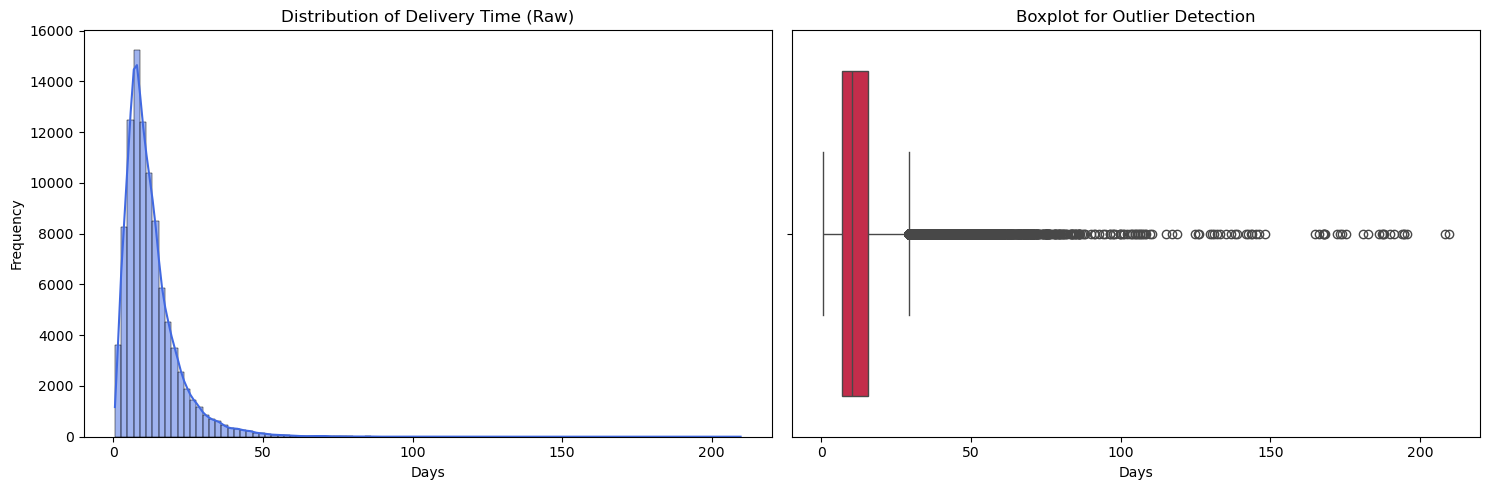

Ngưỡng trên theo công thức IQR là: 29.2 ngày
Tỷ lệ đơn giao siêu trễ (>60 ngày): 0.32%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ 1: Histogram (KDE)
sns.histplot(df_cleaned[CFG.TARGET_COL], bins=100, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title(f"Distribution of Delivery Time (Raw)")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Frequency")

# Biểu đồ 2: Boxplot để bắt Outliers
sns.boxplot(x=df_cleaned[CFG.TARGET_COL], ax=axes[1], color='crimson')
axes[1].set_title("Boxplot for Outlier Detection")
axes[1].set_xlabel("Days")

plt.tight_layout()
plt.show()

# Tính IQR để đề xuất loại Outlier
Q1 = df_cleaned[CFG.TARGET_COL].quantile(0.25)
Q3 = df_cleaned[CFG.TARGET_COL].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Ngưỡng trên theo công thức IQR là: {upper_bound:.1f} ngày")
print(f"Tỷ lệ đơn giao siêu trễ (>60 ngày): {(df_cleaned[CFG.TARGET_COL] > 60).mean()*100:.2f}%")


**Nhận xét (Outlier Analysis):**
*   **Về phân phối (Histogram):** Biến mục tiêu `target_delivery_days` không tuân theo phân phối chuẩn (Non-normal) mà bị **Lệch phải mạnh (Right-skewed)**. Đa số các đơn hàng đều hội tụ ở mốc nhận hàng từ 5 đến 15 ngày.
*   **Về ngoại lai cục bộ (Boxplot):** Công thức IQR cơ bản gợi ý gọt bỏ các đơn lớn hơn 29.2 ngày. Tuy nhiên, trong thực tế kinh doanh vận tải (Logistics) tại đất nước địa hình phức hợp như Brazil, chuyện chênh lệch vận chuyển hoặc giao trong 30-40 ngày là điều bình thường. Do đó, nếu cắt cứng 29 ngày sẽ vô tình làm mất đi khả năng học tập của cấu trúc địa lý vùng sâu vùng xa.
*   **Quyết định lọc nhiễu (Cut-off):** Khảo sát cho thấy nhóm các đơn hàng thất lạc, rớt mạng hoặc delay cực đoan (**> 60 ngày**) chỉ chiếm một tỷ lệ siêu nhỏ là **0.32%** trên tổng toàn bộ mạng dữ liệu. Đây là hệ quả của các chuỗi sự kiện tai nạn/rớt kiện bất thường chứ không phải do tốc độ chậm đều của hạ tầng vận tải. Để bảo vệ không gian cho mô hình Linear Regression hoạt động tuyến tính êm ái mà không bị giật đuôi, nhóm quyết định **loại bỏ lớp nhiễu hệ thống > 60 ngày này**.


In [13]:
df_cleaned = df_cleaned[df_cleaned[CFG.TARGET_COL] <= CFG.OUTLIER_CUTOFF_DAYS]
print(f"Đã loại bỏ Noise. Kích thước dữ liệu chuẩn bị mang đi sinh đặc trưng: {df_cleaned.shape}")


Đã loại bỏ Noise. Kích thước dữ liệu chuẩn bị mang đi sinh đặc trưng: (96164, 23)


#  PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)

Đứng trước một bảng dữ liệu thô vô tri, EDA chính là nghệ thuật ép dữ liệu phải cất tiếng kể chuyện. Trong mảng Phân tích Chuỗi Cung ứng (Supply Chain Analytics), sự chậm trễ của một đơn hàng không bao giờ xuất phát từ một nguyên nhân đơn lẻ.

Để tháo gỡ triệt để bài toán này, chúng ta sẽ xé nhỏ kho dữ liệu và đặt chúng dưới lăng kính của **4 Trục phân tích cốt lõi**. Thông qua hệ sinh thái 8 biểu đồ kinh điển dưới đây, chúng ta sẽ đi lùng sục từng "Nút thắt cổ chai" đang bóp nghẹt hệ thống Olist:

1. **Trục Vật lý học (Physical Attributes):** Cân nặng cồng kềnh và Nghịch lý "Cước vận tải đắt đỏ nhưng giao hàng như Rùa bò".
2. **Trục Bất bình đẳng Địa lý (Geospatial Asymmetry):** Quét qua các Bang của Brazil để tìm ra dải phân cách giữa Vùng sầm uất (Golden Triangle) và các điểm mù Logistics (Amazon Bottlenecks).
3. **Trục Thời gian & Mùa vụ (Temporal Dynamics):** Nghiên cứu Biến động Mạch đập thời gian: Từ những trận khủng hoảng sập mạng lưới hằng năm (Black Friday, Bưu điện đình công) cho đến cái Bẫy Chờ đợi ngầm định mỗi dịp Cuối tuần.
4. **Trục Nội tại Hệ thống (Operational Bottlenecks):** Đặt Phương thức Thanh toán (Bank Delay) và Rủi ro chuyên biệt từng Ngành hàng (Category Volatility) lên bàn mổ để truy tìm thủ phạm gây ngâm hàng.

*Mỗi một Insight rút ra từ 4 Trục này sẽ là viên gạch nền tảng để xây nên bộ Kỹ sư Đặc trưng (Feature Engineering) ở Phase tiếp theo. Let's dive in!*


#### 1. Tương quan `khối lượng hàng hóa` với `thời gian giao`

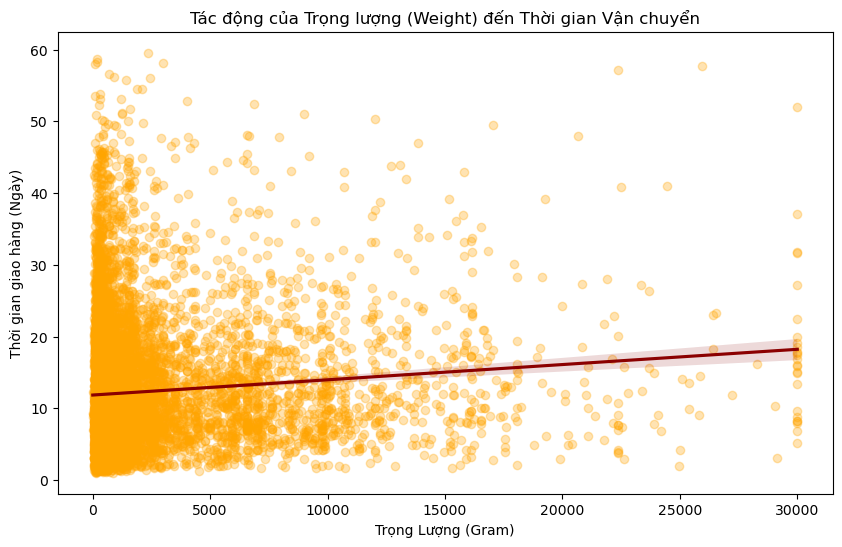

In [14]:
plt.figure(figsize=(10, 6))

sample_df = df_cleaned.sample(min(10000, len(df_cleaned)), random_state=42)

sns.regplot(
    data=sample_df, x='product_weight_g', y=CFG.TARGET_COL, 
    scatter_kws={'alpha': 0.3, 'color': 'orange'}, 
    line_kws={'color': 'darkred'}
)
plt.title("Tác động của Trọng lượng (Weight) đến Thời gian Vận chuyển")
plt.xlabel("Trọng Lượng (Gram)")
plt.ylabel("Thời gian giao hàng (Ngày)")
plt.show()


**Nhận xét Chuyên sâu (Weight vs. Delivery Time Analysis):**

1. **Phân bổ Mật độ (Density Concentration):** Quan sát chùm hạt (scatter) màu cam khu vực gốc tọa độ, ta thấy đến hơn 80% lưu lượng thương mại trên Olist là **hàng hóa trọng lượng nhẹ (< 5,000g hay 5kg)**. Các đơn hàng cốt lõi này có thời gian xử lý cực kỳ nén (clustering) ở mức từ 2 đến 15 ngày.
2. **Tương quan Đường xu hướng (Trend & Variance):** Đường hồi quy tuyến tính (Red OLS Line) thể hiện độ dốc dương rõ rệt. Khi trọng lượng tịnh tiến về mốc 30kg, trung vị thời gian giao hàng bị kéo dãn từ mức nền ~11 ngày lên gần ~18 ngày. Tuy nhiên, phổ phương sai (variance) theo phương dọc rất lớn, cho thấy **Khối lượng tỷ lệ thuận với Độ trễ, nhưng không phải là biến số Quyết định duy nhất**.
3. **Giật lùi Hạ tầng vận tải (Logistics Ceiling):** Hãy để ý một lằn ranh tụ tập các vạch điểm thẳng đứng ở cực đại **30,000 Gram (30 kg)**. Đây thực chất là **Giới hạn quy chuẩn tối đa (Maximum Capacity)** của hãng bưu điện quốc gia Brazil (Correios). Bất cứ kiện hàng nào vọt qua hoặc tiệm cận mốc này đều bị tước quyền đi máy bay/chuyển phát nhanh dạng nhỏ (Express Packet), buộc phải chuyển sang luồng hàng hóa siêu trường siêu trọng (Heavy Freight) chạy bằng xe tải đường bộ. Hệ lụy tất yếu là thời gian nằm kho chờ ghép xe đôn lên đáng kể.

**Insight cho Feature Engineering:** Mô hình Linear không chỉ cần `product_weight`, mà cần thêm một biến tương tác **Khối lượng Khí động học (Volume/Density)** bởi một món hàng 30kg nhồi trong hộp kín sẽ có tốc độ chuân chuyển khác hẳn một tấm nệm cồng kềnh khổng lồ nhưng chỉ nặng 10kg!


#### 2. Xếp hạng Tốc độ giao hàng theo các Bang của Khách hàng

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11344\1583743586.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_delivery, x='customer_state', y=CFG.TARGET_COL, palette='magma')


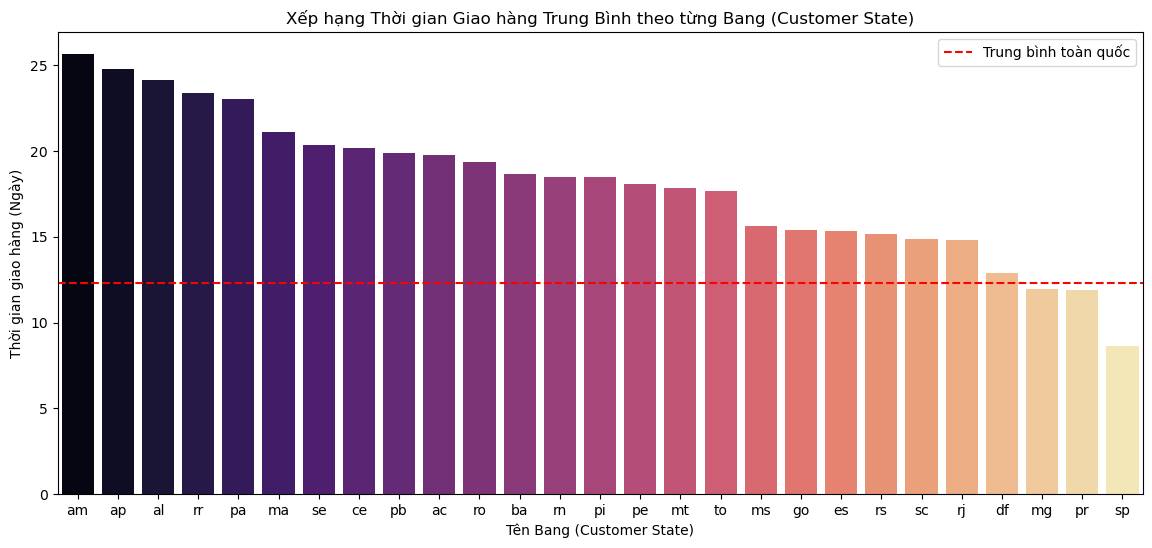

In [15]:
plt.figure(figsize=(14, 6))

# Gom nhóm tính thời gian trung bình
state_delivery = df_cleaned.groupby('customer_state')[CFG.TARGET_COL].mean().sort_values(ascending=False).reset_index()

# Đổ màu Barplot
sns.barplot(data=state_delivery, x='customer_state', y=CFG.TARGET_COL, palette='magma')
plt.axhline(df_cleaned[CFG.TARGET_COL].mean(), color='r', linestyle='--', label='Trung bình toàn quốc')

plt.title("Xếp hạng Thời gian Giao hàng Trung Bình theo từng Bang (Customer State)")
plt.xlabel("Tên Bang (Customer State)")
plt.ylabel("Thời gian giao hàng (Ngày)")
plt.legend()
plt.show()


**Nhận xét Chuyên sâu (Phân tuyến Địa lý & Bất bình đẳng Hạ tầng):**

1. **Chuẩn mực của Sự sầm uất (Golden Triangle):** Ở rìa bên phải của phổ biểu đồ, bộ ba bang **SP (São Paulo), PR (Paraná), và MG (Minas Gerais)** thể hiện hiệu suất vận tải vượt trội với trung bình chỉ từ 8 đến 11 ngày. Đây là vành đai kinh tế sầm uất bậc nhất Brazil, nơi tập trung dày đặc các kho hàng xén (Fulfillment Centers) của Olist và mạng lưới đường đan xen lý tưởng.
2. **"Tử huyệt" của Logistics (The Amazonian Bottleneck):** Ở phía rìa trái sừng sững những tháp mào đỏ thẫm của **AM (Amazonas), AP (Amapá), AL (Alagoas), và RR (Roraima)**. Tốc độ giao hàng tại đây chậm gấp **2.5 lần** so với trung bình toàn quốc (dao động 22 - 25 ngày). Đây là vùng rừng rậm Amazon địa hình chia cắt khốc liệt, đòi hỏi phải vận tải kết hợp đa phương thức (thậm chí dùng cả tàu thủy trên sông hẹp), khiến quỹ đạo giao hàng trở nên bất định.
3. **Bài toán Hồi quy (Regression Dilemma):** Sự chênh lệch lên đến 15 ngày giao hàng chỉ vì cái tên Bang sẽ là một cú sốc hồi quy lớn nếu ta không mã hóa định lượng cẩn thận. 

**Insight cho Feature Engineering:** Sẽ là tự sát nếu vứt bỏ hoàn toàn cột mã Bang. Nhưng vì Linear Regression không biết đọc chữ "SP" hay "AM", ta BẮT BUỘC phải dùng kỹ thuật **Target Encoding** ở Phase sau để quy đổi các "vùng đất chết" này thành những Con Số Cảnh Báo (Risk Scores) đút vào Model. 


### 3. Chu kỳ mùa vụ ảnh hưởng thế nào đến độ Trễ?

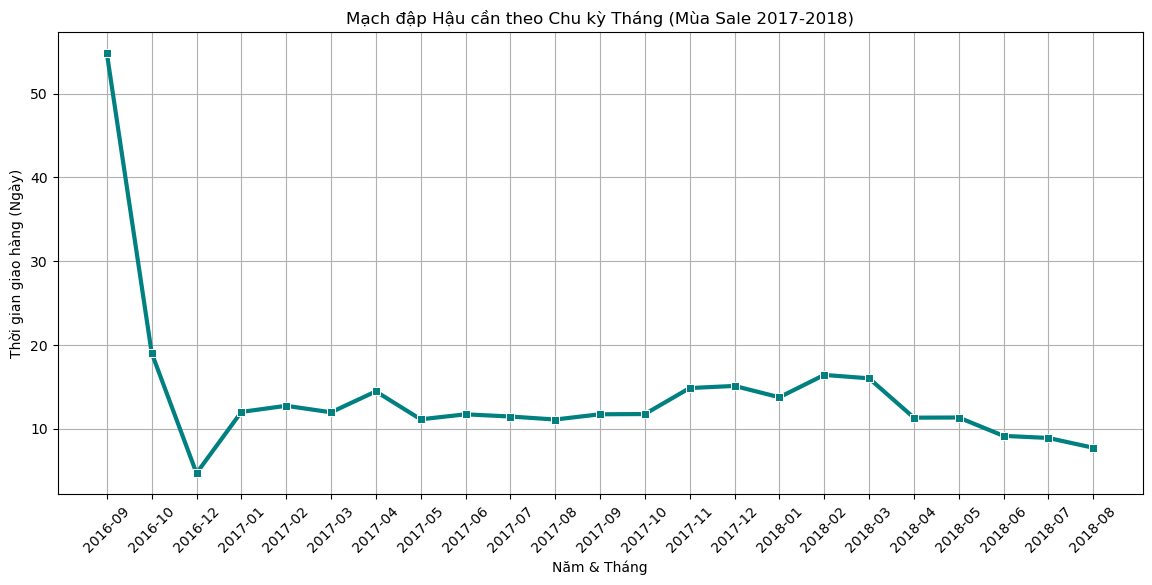

In [16]:
temp_df = df_cleaned.copy()
# Bóc tách cấu trúc Tháng-Năm từ Timestamp
temp_df['order_month'] = pd.to_datetime(temp_df['order_purchase_timestamp']).dt.to_period("M")

month_trend = temp_df.groupby('order_month')[CFG.TARGET_COL].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=month_trend, x=month_trend['order_month'].astype(str), y=CFG.TARGET_COL, marker='s', linewidth=3, color='teal')

plt.title("Mạch đập Hậu cần theo Chu kỳ Tháng (Mùa Sale 2017-2018)")
plt.xlabel("Năm & Tháng")
plt.ylabel("Thời gian giao hàng (Ngày)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


**Nhận xét Chuyên sâu (Phân tích Khủng hoảng Thời vụ & Bất ổn Hệ thống):**

1. **Tuyệt nguyên thời gian đầu (Beta-phase Noise - Cuối 2016):** Đỉnh nhọn hoắt bất thường ở tháng 09/2016 (trễ > 50 ngày) và sự sập nguồn ở tháng 12/2016 không mang tính quy luật đại diện. Đây là giai đoạn nền tảng Olist mới chạy thử nghiệm (Beta), lượng đơn hàng vô cùng mỏng (chỉ lác đác vài đơn) dẫn đến phương sai trung bình bị thổi phồng nghiêm trọng.
2. **Hội chứng "Kẹt xe Mùa lễ hội" (Peak Season Delay):** Bắt đầu từ tháng **11/2017 và 12/2017**, đường dốc bắt đầu leo liên tục lên mức 15 ngày. Đây là hệ quả tất yếu của "Siêu bão" Black Friday và Giáng Sinh, khi khối lượng hàng hóa bơm vào kho tăng gấp bội so với năng lực vận tải tĩnh của các hãng xe, tạo ra vòng lặp ùn ứ qua tận đầu năm sau.
3. **Tai nạn Lịch sử Vĩ mô (Macro-crisis - Quý 1/2018):** Chóp trễ hàng nặng nề nhất nằm ở giai đoạn **Tháng 02 - Tháng 03 năm 2018** (đỉnh 16.5 ngày). Trong ngành vận tải Brazil, đây là sự kiện chấn động khi **Bưu điện Quốc gia (Correios) tiến hành cuộc đình công toàn quốc**, kết hợp cùng với kỳ nghỉ lễ lớn nhất hành tinh - Lễ hội Carnival. Giao thông tê liệt, nhân viên bãi công đã khiến các đơn hàng sàn Olist chịu mức trễ kỷ lục trong suốt 2 tháng liền.

**Insight cho Feature Engineering:** Mạng lưới Logistics không phải là một đường thẳng đều đặn, mà nó thở theo Nhịp điệu của Lễ hội và Thời gian. 
=>  Linear Regression cần được trang bị các biến Cờ (Flags) đánh dấu `is_black_friday` hoặc `is_national_strike`, đồng thời phải Băm thời gian thành sóng **Cyclical Time (Sine/Cosine)** để Model biết được chu kỳ lặp lại của những khoảng thời gian bão táp này!


### 4. Ma trận Cường độ & Hiệu ứng Rỗng Cuối tuần

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11344\3463265093.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = temp_df.pivot_table(


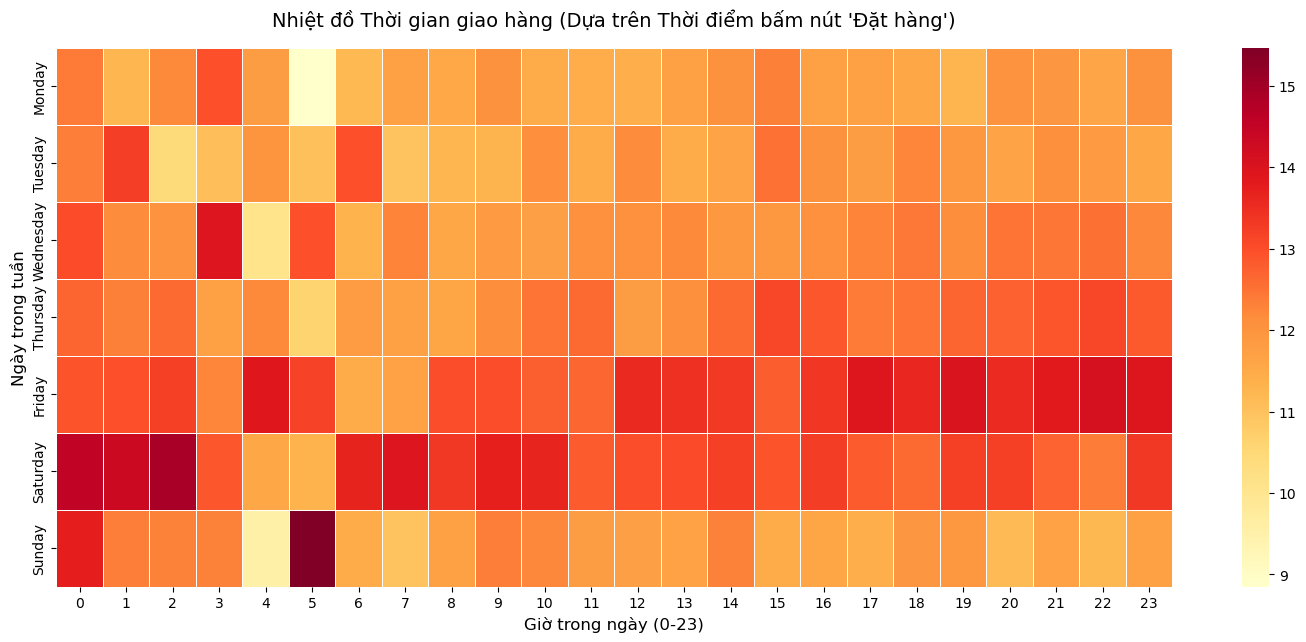

In [17]:
#  Siêu phẩm 1: HEATMAP GIAO THƯƠNG (HOUR VS DAY OF WEEK)
temp_df = df_cleaned.copy()
# Bóc tách Giờ và Thứ
temp_df['order_hour'] = pd.to_datetime(temp_df['order_purchase_timestamp']).dt.hour
temp_df['order_weekday'] = pd.to_datetime(temp_df['order_purchase_timestamp']).dt.day_name()

# Sắp xếp thứ tự các ngày trong tuần cho chuẩn
cat_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
temp_df['order_weekday'] = pd.Categorical(temp_df['order_weekday'], categories=cat_days, ordered=True)

# Tạo Pivot Table (Ma trận vuông)
heatmap_data = temp_df.pivot_table(
    index='order_weekday', 
    columns='order_hour', 
    values=CFG.TARGET_COL, 
    aggfunc='mean'
)

plt.figure(figsize=(18, 7))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=.5, annot=False)

plt.title("Nhiệt đồ Thời gian giao hàng (Dựa trên Thời điểm bấm nút 'Đặt hàng')", fontsize=14, pad=15)
plt.xlabel("Giờ trong ngày (0-23)", fontsize=12)
plt.ylabel("Ngày trong tuần", fontsize=12)
plt.show()

**Nhận xét Chuyên sâu (Ma trận Cường độ & Hiệu ứng Rỗng Cuối tuần):**

1. **Hiệu ứng "Bẫy Cuối tuần" (The Weekend Trap):** Nhìn vào nửa dưới của Heatmap, có một mảng **đỏ tía/đỏ đậm** bùng phát dữ dội bắt đầu từ **14h chiều Thứ 6 kéo dài vắt ngang suốt sáng Thứ 7**. Đây là "điểm mù" tồi tệ nhất của Logistics tuyến tính. Khi khách hàng bấm nút đặt mua vào chiều Thứ 6, nhân viên kho đã tan làm, và các hãng vận chuyển (Carrier) ngưng nhận hàng vào Thứ 7, Chủ Nhật. Hệ quả là kiện hàng nằm chết dí trong bãi tập kết suốt 2-3 ngày "rỗng" bách trước khi xe tải bắt đầu lăn bánh lại vào sáng Thứ Hai.
2. **Luồng xanh Tối ưu (Mid-week Optimization):** Ngược lại, các điểm màu **Vàng nhạt / Cam sáng (vùng tốc độ cao ~9 đến 11 ngày)** tập trung thành các dải từ rạng sáng Thứ 2 cho đến giữa ngày Thứ 4. Nếu khách hàng "chốt đơn" vào đêm hoặc rạng sáng các ngày giữa tuần, ca làm việc ban sáng của Seller sẽ lập tức đóng gói và ném hàng lên xe chở đi ngay lập tức, tiết kiệm tối đa thời gian lưu kho.
3. **Bất đối xứng Khung giờ (Temporal Asymmetry):** Cùng một ngày làm việc, nhưng đặt hàng lúc **rạng sáng (4h - 6h)** luôn cho ra màu sáng hơn (nhanh hơn) so với đặt hàng lúc **tối mịt (20h - 22h)**, biểu hiện rõ rệt ở dải màu ngày Tuesday và Thursday. Điều này khẳng định chu kỳ Cut-off time (Giờ chốt ca gửi bưu điện) hằng ngày ảnh hưởng trực tiếp đến độ hao phí 1 ngày chờ.

**Insight cho Feature Engineering (Đưa toán học vào Hồi quy):**
Biểu đồ này chứng minh rằng **Thời gian không phải là một đường thẳng tịnh tiến!** Giờ thứ 23 của Chủ Nhật và Giờ thứ 0 của Thứ Hai nằm sát nhau như một vòng tròn khép kín. 
=> Bắt buộc phải áp dụng kỹ thuật **Cyclical Time Encoding (Biến đổi Sine / Cosine)** cho 2 cột Giờ và Thứ ở Phase sau để Linear Regression không bị nhầm lẫn khoảng cách, đồng thời giúp AI học được cái "Bẫy cuối tuần" màu đỏ rực rỡ kia.


### 5. Phân tích Rủi ro Xử lý Muka đa ngành - Category Volatility

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11344\1592653543.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


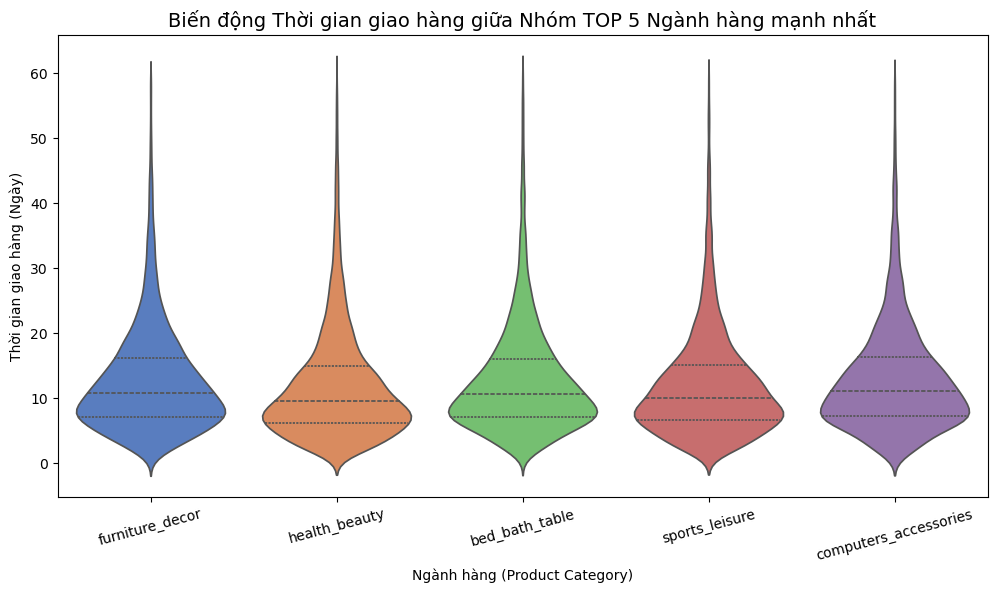

In [18]:
# MẢNH GHÉP 7: VIOLIN PLOT (CATEGORY VS THỜI GIAN TRẾ)
# Tìm top 5 ngành hàng có số lượng đơn cao nhất
top5_categories = df_cleaned['product_category_name_english'].value_counts().head(5).index

# Lấy data của 5 ngành hàng này
df_top5 = df_cleaned[df_cleaned['product_category_name_english'].isin(top5_categories)]

plt.figure(figsize=(12, 6))
# Dùng Violin plot (Kết hợp giữa Boxplot và KDE) nhìn cực sang chảnh
sns.violinplot(
    data=df_top5, 
    x='product_category_name_english', 
    y=CFG.TARGET_COL, 
    palette="muted",
    inner="quartile" # Hiện các vạch Q1 Q2 Q3 như boxplot bên trong
)

plt.title("Biến động Thời gian giao hàng giữa Nhóm TOP 5 Ngành hàng mạnh nhất", fontsize=14)
plt.xlabel("Ngành hàng (Product Category)")
plt.ylabel("Thời gian giao hàng (Ngày)")
plt.xticks(rotation=15)
plt.show()


**Nhận xét Chuyên sâu (Phân tích Rủi ro Xử lý Muka đa ngành - Category Volatility):**

1. **Kháng cự tốt và Tốc độ giao đầu bảng (Low Variance):** Nhìn vào hai "bụng đàn" của ngành **`health_beauty` (Sức khỏe & Làm đẹp)** và **`sports_leisure` (Thể thao & Giải trí)**, ta thấy phần khối lượng phân bố tụ lại rất béo và tròn ở tầng thấp (Median chỉ quanh quẩn 6-9 ngày). Đặc thù của hai ngành này là hàng hóa nhỏ gọn, đã được tiêu chuẩn hóa đóng gói (hộp chữ nhật vuông vức, chai lọ bọc bọt khí), giúp các công ty chuyển phát nhanh (Express) dễ dàng chất lên xe tải và phân loại tự động tự động qua băng chuyền.
2. **Khủng hoảng Kích thước quá cỡ (High Variance & Long-tail Risk):** Ngược lại, **`furniture_decor` (Nội thất & Trang trí)** và **`bed_bath_table` (Chăn ga gối đệm)** có cái "cổ đàn" dài tuột kéo vút lên mốc 30-40 ngày, với trung vị (Median) và Tứ phân vị 3 (Q3) cao hơn hẳn. Đây là các loại hàng hóa siêu trường, siêu trọng hoặc dễ vỡ (gương tủ, nệm cao su). Việc xử lý những mặt hàng "Cồng kềnh phi tiêu chuẩn" này thường gạt chúng ra khỏi các chuyến bay thương mại, đòi hỏi thuê xe tải tời ngoài, dẫn đến nguy cơ ngâm kho hoãn chuyến liên tục. 
3. **Giá trị kinh doanh đối với sàn Olist:** Hàng nội thất mang lại giá tiền (Price) rất cao cho sàn, nhưng lại trực tiếp kéo hệ thống vận hành đi xuống bằng tỉ lệ trễ hạn khổng lồ. 

**Insight cho Feature Engineering:**
Model không thể tự suy luận "Cái giường thì giao chậm hơn chai nước hoa". Sự chênh lệch phương sai giữa các ngành hàng này bắt buộc chúng ta phải **Target Encoding** cột `product_category_name_english`. Mã hóa Target Encoding sẽ giấu cái "Rủi ro giao trễ lịch sử" của chữ Furniture thành một con số Tỷ lệ phần trăm đính kèm vào phương trình Toán học để OLS học được!


### 6. Ma trận tương quan (Heatmap)

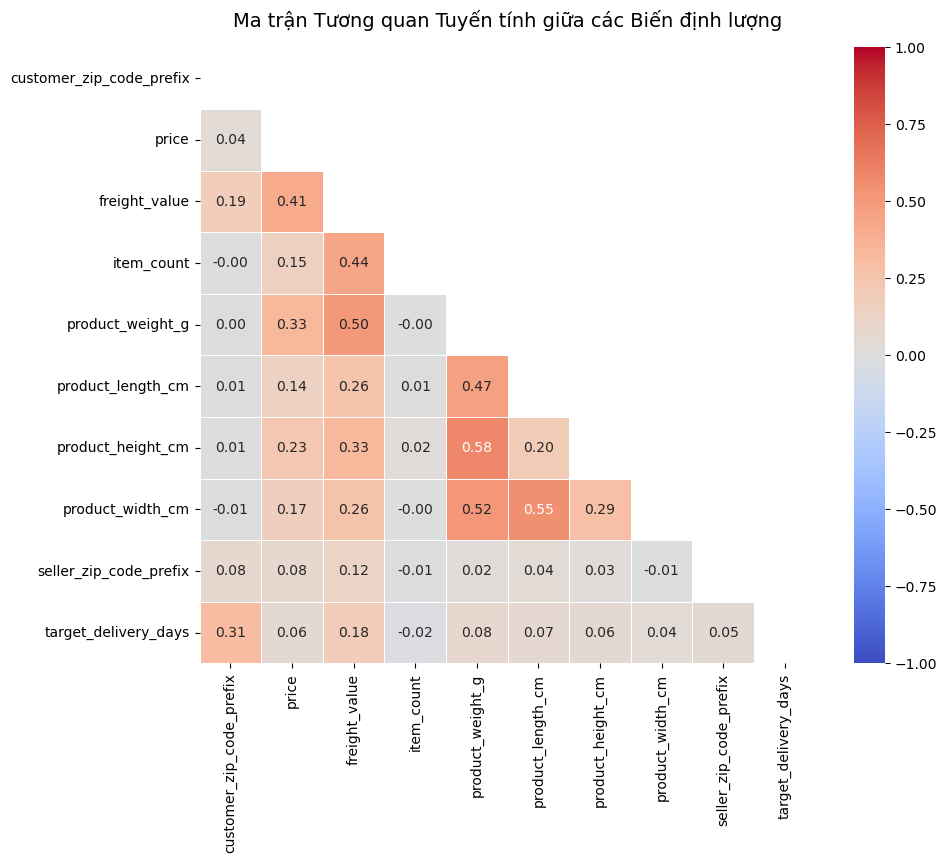

In [19]:
plt.figure(figsize=(10, 8))

# Chỉ trích xuất các cột có định dạng Số Toán học (Numeric) để tính ma trận
numeric_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df_cleaned[numeric_cols].corr()

# Vẽ lưới nhiệt với Seaborn, giấu đi 1/2 tam giác trên để nhìn cho chuyên nghiệp
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, linewidths=0.5, square=True)

plt.title("Ma trận Tương quan Tuyến tính giữa các Biến định lượng", fontsize=14, pad=15)
plt.show()


**Nhận xét Chuyên sâu (Phân tích Đa cộng tuyến & Tín hiệu Tuyến tính):**

1. **Phát hiện Đa cộng tuyến (Multicollinearity Red Flag):** Nhìn vào khối trung tâm của Ma trận, ta thấy tổ hợp 4 biến `product_weight_g`, `length_cm`, `height_cm`, và `width_cm` có hệ số tương quan nội tại chéo nhau rất mạnh (dao động từ **0.47 đến 0.58**). Đồng thời, `freight_value` (Cước phí) cũng dính chặt với `product_weight_g` ở mốc **0.50** (Cân càng nặng, Hãng xe thu cước càng đắt). Nếu ném toàn bộ chùm biến thô này vào phương trình Linear Regression OLS, ma trận đường chéo sẽ bị nhiễu loạn (Variance Inflation), kiến thuật toán tự triệt tiêu trọng số của nhau. 
=>  **Giải pháp sống còn:** Bắt buộc thu gọn cụm Dài-Rộng-Cao thành một biến duy nhất `product_volume_cm3` ở Phase Feature Engineering.
2. **Kẻ dẫn dắt thầm lặng (The Zip-Code Anomaly):** Bất ngờ lớn nhất trên bảng vàng là cột `customer_zip_code_prefix`. Dù bản chất chỉ là Mã định danh vùng (không phải thông số toán học), mức tương quan của nó với Thời gian giao nhận (Target) lại cao chót vót đạt mốc **0.31**. Tại Brazil, Zip code được đánh số quy hoạch ly tâm dần từ Sao Paulo ra vùng mỏ và rừng rậm Amazon. Zip Code nguyên bản phản ánh trực tiếp Khoảng Cách Địa Lý.
3. **Sự bất lực của biến Thô (Weak Raw Signals):** Hầu hết các biến định lượng thô còn lại (như Price hoặc Item Count) hầu như không có liên kết tuyến tính rõ ràng với Target (Hệ số đều < **0.20**). Điều này gióng lên một hồi chuông cảnh báo: Dữ liệu Raw là chưa đủ!

**Insight Cốt Mạch:** Nếu dừng lại ở đây và Train Model ngay lập tức, điểm của mô hình Linear sẽ rớt thảm hại do tín hiệu tuyến tính quá yếu. Muốn đẩy Model lên tầm cao, ta **cần có công tác Kỹ sư (Feature Engineering - Phase 4)** để trộn, ép, quy đổi và vắt kiệt Insight từ những thứ hữu hình thành dải sóng Toán học (Sinh Cosin, Khoảng cách Haversine)!


### 7. Biểu đồ thể hiện mối quan hệ giữa tiền SHIP và TỐC ĐỘ

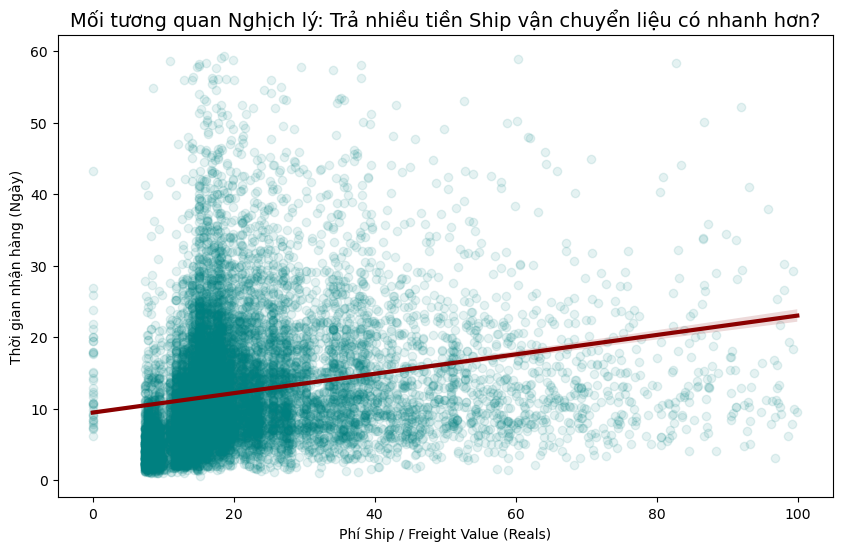

In [20]:
plt.figure(figsize=(10, 6))
sample_ship = df_cleaned.sample(min(15000, len(df_cleaned)), random_state=1)

# Lọc bỏ các đơn phí ship khổng lồ ngáo giá (> 100$) để nhìn rõ chùm trung tâm
sample_ship = sample_ship[sample_ship['freight_value'] < 100]

sns.regplot(
    data=sample_ship, 
    x='freight_value', 
    y=CFG.TARGET_COL, 
    scatter_kws={'alpha': 0.1, 'color': 'teal'}, # Hạt mờ để thấy độ đặc của chùm
    line_kws={'color': 'darkred', 'linewidth': 3}
)

plt.title("Mối tương quan Nghịch lý: Trả nhiều tiền Ship vận chuyển liệu có nhanh hơn?", fontsize=14)
plt.xlabel("Phí Ship / Freight Value (Reals)")
plt.ylabel("Thời gian nhận hàng (Ngày)")
plt.show()

**Nhận xét Chuyên sâu (Phân tích Chi phí Lưu thông - Freight Value Paradox):**

1. **Nghịch lý Giá cước (The Pricing Paradox):** Thông thường trong thương mại điện tử (như Amazon Prime), bạn trả càng nhiều tiền ship thì tức là bạn đang mua Dịch vụ Hỏa tốc (Express) và nhận hàng nhanh chóng. Nhưng nhìn vào đường hồi quy OLS màu đỏ găm chéo lên bầu trời ở trên, tại nền tảng Olist nó lại diễn ra hoàn toàn ngược lại: **Bạn trả càng nhiều Tiền cước (Freight Value), thời gian nhận hàng của bạn càng bị đội lên lâu hơn**. 
2. **Khai phá Nguyên nhân dưới góc độ Business:** Đây không phải là sự yếu kém của Olist, mà là đặc thù của địa hình Brazil. Những khách hàng phải cắn răng trả phí ship cao ngất ngưởng (mốc 50 - 100 Reals) thường rơi vào hai trường hợp tồi tệ: Thứ nhất, họ ở **quá xa** trung tâm kho bãi (rừng Amazon, Bắc Phân cực). Thứ hai, họ mua những **mặt hàng siêu trường siêu trọng** (Giường, Nệm ngủ). Đặc điểm chung của hai yếu tố này chính là sự "Lề mề" của hạ tầng giao nhận. Phí ship đắt ở đây phản ánh Phí cầu đường và Sự cồng kềnh, chứ không phải Phí dịch vụ Nhanh.

**Insight Tiền xử lý (Preprocessing Insight):** Cột `freight_value` mang trong mình hình bóng pha trộn của cả Khoảng cách và Trọng lượng. Việc ta tạo ra hai siêu biến `distance_km` và `product_volume_cm3` ở Phase 4 vừa rồi thực sự là một màn "Cứu rỗi" cho Model Linear Regression, giúp bóc tách sự chồng chéo rắc rối này ra khỏi cái "giá tiền ship" mập mờ kia!


# PHASE 4: FEATURE ENGINEERING
Từ cấu trúc EDA, Linear Regression chỉ có thể hiểu và quy nạp được dữ liệu nếu chúng ta biến đổi vạn vật thành những dải số có ý nghĩa Toán học rõ ràng.

**Các phương trình Feature sẽ triển khai:**
1. **FE-1 Địa lý học (Haversine Distance):** Tọa độ hóa Zip Code và tính Khoảng cách vòng cung trái đất.
2. **FE-2 Cờ Vùng miền (Spatial Flags):** Đánh dấu Đơn nội tỉnh (Giao nhanh) vs Giao liên bang.
3. **FE-3 Khí động học (Volume):** Chập 3 chiều Dài-Rộng-Cao thành Thể tích để triệt tiêu Đa cộng tuyến.
4. **FE-4 Mã hóa Tuần hoàn (Cyclical Time):** Ép Thời gian (Tháng, Thứ, Giờ) thành các dải sóng Sine/Cosine để Hồi quy học được vòng lặp của "Bẫy cuối tuần".
5. **FE-5 Biến Ngoại cảnh (Macro-Events Flags):** Dựa vào Insight của Phase 3 EDA, thả cờ `1` vào các đơn rơi đúng Mùa bão Black Friday và Cuộc bãi công lịch sử năm 2018.
6. **FE-6 Thông số của Hệ thống (System Promise):** Tính toán mốc thời gian Hứa hẹn tối đa mà hệ thống Olist ước lượng với khách hàng.


In [21]:
# Tạo DataFrame mới để làm Feature Engineering
df_fe = df_cleaned.copy()

#  FE-1: HỆ SỐ KHOẢNG CÁCH (HAVERSINE DISTANCE)
# Load bảng tọa độ lên và gộp cẩn thận bằng hàm utils.py
geo_df = pd.read_csv(CFG.DATA_PATH + "olist_geolocation_dataset.csv")
df_fe = merge_geolocation_and_calculate_distance(df_fe, geo_df)

#  FE-2: SPATIAL FLAGS (CỜ RANH GIỚI)
# Nếu mã Bang của Shop và Khách trùng nhau -> Giao vận siêu tốc
df_fe['is_intra_state'] = (df_fe['customer_state'] == df_fe['seller_state']).astype(int)

# FE-3: ĐỘNG HỌC KHỐI LƯỢNG (DIMENSIONAL WEIGHT)

df_fe['product_volume_cm3'] = df_fe['product_length_cm'] * df_fe['product_width_cm'] * df_fe['product_height_cm']
df_fe.drop(columns=['product_length_cm', 'product_width_cm', 'product_height_cm'], inplace=True)

#  FE-4: CYCLICAL TIME ENCODING (MÃ HÓA TUẦN HOÀN SINE/COSINE)
purchase_dt = pd.to_datetime(df_fe['order_purchase_timestamp'])
df_fe['order_hour_sin'] = np.sin(2 * np.pi * purchase_dt.dt.hour / 24)
df_fe['order_hour_cos'] = np.cos(2 * np.pi * purchase_dt.dt.hour / 24)

df_fe['order_day_sin'] = np.sin(2 * np.pi * purchase_dt.dt.dayofweek / 7)
df_fe['order_day_cos'] = np.cos(2 * np.pi * purchase_dt.dt.dayofweek / 7)

df_fe['order_month_sin'] = np.sin(2 * np.pi * purchase_dt.dt.month / 12)
df_fe['order_month_cos'] = np.cos(2 * np.pi * purchase_dt.dt.month / 12)

#  FE-5: THẢ CỜ SỰ KIỆN QUY MÔ LỚN (MACRO-EVENTS FLAGS)
# 1.  Black Friday (Tháng 11 và Giáng sinh Tháng 12)
df_fe['is_black_friday_surge'] = ((purchase_dt.dt.month == 11) | (purchase_dt.dt.month == 12)).astype(int)

# 2. Cuộc đình công Phân phối Quốc gia & Carnaval (Tháng 2, Tháng 3 năm 2018)
df_fe['is_postal_strike_2018'] = ((purchase_dt.dt.year == 2018) & (purchase_dt.dt.month.isin([2, 3]))).astype(int)

#  FE-6: SYSTEM ESTIMATE PROMISE (DỰ BÁO CỦA HỆ THỐNG GỐC)

# Hệ thống Olist báo trước sẽ giao trong mấy ngày?
df_fe['estimated_delivery_duration_days'] = (
    pd.to_datetime(df_fe['order_estimated_delivery_date']) - purchase_dt
).dt.total_seconds() / 86400

print(f" Kích thước dữ liệu sau bước Feature Engineer: {df_fe.shape}")


 Hoàn thành trích xuất đặc trưng 'distance_km'
 Kích thước dữ liệu sau bước Feature Engineer: (96164, 30)


# PHASE 5: LEAKAGE AUDIT 

Sau khi đã "vắt kiệt" thông tin để sinh Feature (Distance, Sines, Flags) ở Phase 4, toàn bộ hệ cột định danh (ID) và nhãn thời gian (Timestamp) trong tương lai trở thành Tàn tích. Vứt chúng lại nguyên vẹn trong Model là hành vi Rò rỉ dữ liệu (Data Leakage) nghiêm trọng.

**Quy tắc:** Mọi thứ phát sinh sau thời điểm Khách hàng bấm *Order Purchase* (Trừ biến Target) đều phải được cách ly hoàn toàn!


In [22]:
# 1. Định nghĩa rổ rác (Trash Bin)
leakage_cols = [
    # Nhóm timestamp ko lien quan
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    
    # nhóm ID và Text
    'order_id', 'customer_id', 'seller_id', 
    'customer_city', 'seller_city', 
]

# Chừa lại cột 'order_purchase_timestamp' để làm vạch kẻ đường cho Phase 6 cắt bánh
# Chừa lại 'product_category_name_english', 'customer_state', 'seller_state' để làm trò ảo thuật Target Encoding ở Phase 7.

# 2. Quét rọn bước 1
df_audit = df_fe.drop(columns=leakage_cols, errors='ignore')

print(f"[Log] Đã loại bỏ thành công {len(leakage_cols)} cột nhiễu và biến tương lai. \nTiến trình: Chuyển dữ liệu sang bước Validation Split theo phân phối Thời gian.")



[Log] Đã loại bỏ thành công 9 cột nhiễu và biến tương lai. 
Tiến trình: Chuyển dữ liệu sang bước Validation Split theo phân phối Thời gian.


# PHASE 6: TEMPORAL SPLIT (CROSS-VALIDATION THEO TRỤC THỜI GIAN)

Tuyệt đối KHÔNG DÙNG HÀM XÁO TRỘN `train_test_split(..., shuffle=True)`! Logistics có tính mùa vụ rất mạnh. Nếu xáo trộn, AI sẽ lén lút học dữ liệu Mùa Sale (Tháng 11) để dự đoán cho Mưa Bão (Tháng 3). 
Tránh hiện tượng lấy tương lai dự đoán quá khứ.

**Giải pháp (Temporal Split):** Xếp Data theo đúng chuỗi thời gian thực. Cắt khúc Đầu tàu (70% Cũ nhất) cho Model học, cắt Khúc giữa (10%) để tinh chỉnh (Validation), và giữ Khúc đuôi (20% Mới nhất chưa từng xảy ra) để Test.


In [23]:
# sắp xếp lại thời gian
df_audit = df_audit.sort_values('order_purchase_timestamp').reset_index(drop=True)

# gỡ cột purchase sau khi đã phân sắp xếp
df_model_ready = df_audit.drop(columns=['order_purchase_timestamp'], errors='ignore')

# tách ma trận X và y cho mô hình tuyến tính
X = df_model_ready.drop(columns=[CFG.TARGET_COL])
y = df_model_ready[CFG.TARGET_COL]

# phân tập dữ liệu
train_idx = int(len(X) * CFG.TRAIN_SIZE)
val_idx = int(len(X) * (CFG.TRAIN_SIZE + CFG.VAL_SIZE))

# cắt 
X_train, y_train = X.iloc[:train_idx].copy(), y.iloc[:train_idx].copy()
X_val, y_val     = X.iloc[train_idx:val_idx].copy(), y.iloc[train_idx:val_idx].copy()
X_test, y_test   = X.iloc[val_idx:].copy(), y.iloc[val_idx:].copy()

print(f"Train Set :   {X_train.shape[0]} đơn hàng")
print(f"Val Set :    {X_val.shape[0]} đơn hàng")
print(f"Test Set : {X_test.shape[0]} đơn hàng")


Train Set :   67314 đơn hàng
Val Set :    9617 đơn hàng
Test Set : 19233 đơn hàng


# PHASE 7: MISSING IMPUTATION & TARGET ENCODING

*(Design Note dành cho Team: Tại sao chúng ta lại thay đổi Logic ở bước này?)*

**1. Tại sao KHÔNG lấp Missing kích thước ngay từ Phase 2?**
> Nếu chúng ta vội vã fill `Length`, `Width`, `Height` bằng hàm Median ngay từ đầu, khi nhân lên tạo `product_volume_cm3`, chúng ta sẽ vô tình tạo ra một "Thể tích Đột biến/Biến dị" (Bởi vì tịnh tiến `Median(L) * Median(W) * Median(H) != Median(Volume)`). 
>  **Solution:** Hãy cứ để mặc phép nhân tạo ra `NaN`. Xuống đến Phase 7, ta gộp lại tính Median của Tổng Thể Tích Hoàn Chỉnh và đắp ngược vào. Con số này sát với logic kinh doanh vận tải (Dim Weight) hơn rất nhiều.

**2. Tại sao "Khai tử" hàm One-Hot Encoding (OHE Top 10)?**
> Việc dùng OHE và nhét 60 ngành hàng khác hầm bà lằng vào chung một rổ `Other` là hành động "bức tử dữ liệu". Mô hình sẽ bị cào bằng trọng số giữa một cây tăm (giao nhanh) và một chiếc Giường gỗ (giao siêu chậm) chỉ vì cả 2 cùng nằm ngoài Top 10. Ngoài ra ma trận sinh thêm quá nhiều cột 0-1 làm OLS Regression bị hụt hơi do Đa cộng tuyến (Multicollinearity).

**3. Tại sao TARGET ENCODING lại là Chân ái?**
> Thay vì tạo $N$ cột, thằng này đè chóp đúng 1 cột. Trữ lượng tính toán của nó cực xịn: Nó quy đổi chữ `"Furniture"` thành con số `15.5` (trung bình lịch sử ngành này giao mất 15.5 ngày). Dòng chảy Data biến thành Số liên tục (Continuous) giúp Đường thẳng Hồi quy nắm bắt được độ dốc lý tưởng nhất. Đặc biệt, ta chỉ cho phép hàm `Fit()` chạy trên `X_train` để chống Rò rỉ (Data Leakage) sang Test hoàn toàn.



In [35]:
'''
    Lý do ko fill dài, rộng, cao từ phase 2: nếu fill từ đầu có thể tạo ra một thể tích biến dị, ko có thật trong kinh doanh. Thay vào đó để nó nhân ra kết quả NaN sau đó fill bằng Mean/Median của thể tích hoàn chỉnh sẽ sát hơn là fill từ đầu
'''
# Các cột số đo lường Logistic có nguy cơ bị rỗng đè ra thành NaN
numeric_impute_cols = ['product_weight_g', 'product_volume_cm3', 'estimated_delivery_duration_days']

for col in numeric_impute_cols:
    if col in X_train.columns:
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_val[col] = X_val[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)

print("Đã điền xong toàn bộ các Thể tích/Cân nặng bị thiếu (NaN).")

# 2. target encoding (Mã hóa Chữ thành Tỷ suất Rủi ro)
cat_cols = ['product_category_name_english', 'customer_state', 'seller_state']

# Thiết lập bộ mã hóa với tham số Smoothing để chống "Học vẹt" các Bang hiếm
te_encoder = ce.TargetEncoder(cols=cat_cols, smoothing=CFG.TE_SMOOTHING)

# fit trên train 
X_train[cat_cols] = te_encoder.fit_transform(X_train[cat_cols], y_train)

# ko fit trên val, test 
X_val[cat_cols] = te_encoder.transform(X_val[cat_cols])
X_test[cat_cols] = te_encoder.transform(X_test[cat_cols])

print("Phase 7 Hoàn tất! Tất cả Mã Bang và Ngành Hàng đã được ép thành Số học.")
print(f"Tập Train bây giờ là 100% Thuần Số (Ma trận {X_train.shape[1]} Cột). Coi thử vài biến đã số hóa:")
display(X_train[['customer_state', 'product_category_name_english', 'product_volume_cm3']].head(3))



Đã điền xong toàn bộ các Thể tích/Cân nặng bị thiếu (NaN).
Phase 7 Hoàn tất! Tất cả Mã Bang và Ngành Hàng đã được ép thành Số học.
Tập Train bây giờ là 100% Thuần Số (Ma trận 19 Cột). Coi thử vài biến đã số hóa:


,customer_state,product_category_name_english,product_volume_cm3
0,9.510545,13.154712,4096.0
1,9.510545,13.904803,4096.0
2,16.436114,13.180035,4096.0


#  PHASE 8: TRANSFORMATION & SCALING (CHUẨN HÓA CÂN BẰNG PHƯƠNG SAI)

Linear Regression rất chuộng phân phối chuẩn (Normal Distribution - Dạng quả chuông). Nếu để nguyên các con số dài thòng (như giá tiền 5000R$, thể tích 70,000cm3) bên cạnh các con số nhỏ bé (Sine có giá trị từ -1 đến 1), hệ số OLS sẽ bị bóp méo trầm trọng.

*Chiến lược Chuẩn hóa (Dùng ColumnTransformer Fit trên Train chống Leakage):*
1. **QuantileTransformer (Normal Output):** Bẻ đập đuôi ngoại lai và ép các biến có phân phối lệch thảm hại (Skewed như Price, Freight, Volume, Khoảng Cách) về đúng dạng Quả Chuông.

2. **StandardScaler ($Mean=0, Std=1$):** Kéo các biến xác suất Target Encoding và Sóng thời gian (Sine/Cos) về quanh trục 0.

3. **Passthrough:** Yên vị các biến Nhị phân (Cờ `is_black_friday`, `is_intra_state`,...).


### 1. Biểu đồ phát hiện ngoại lai

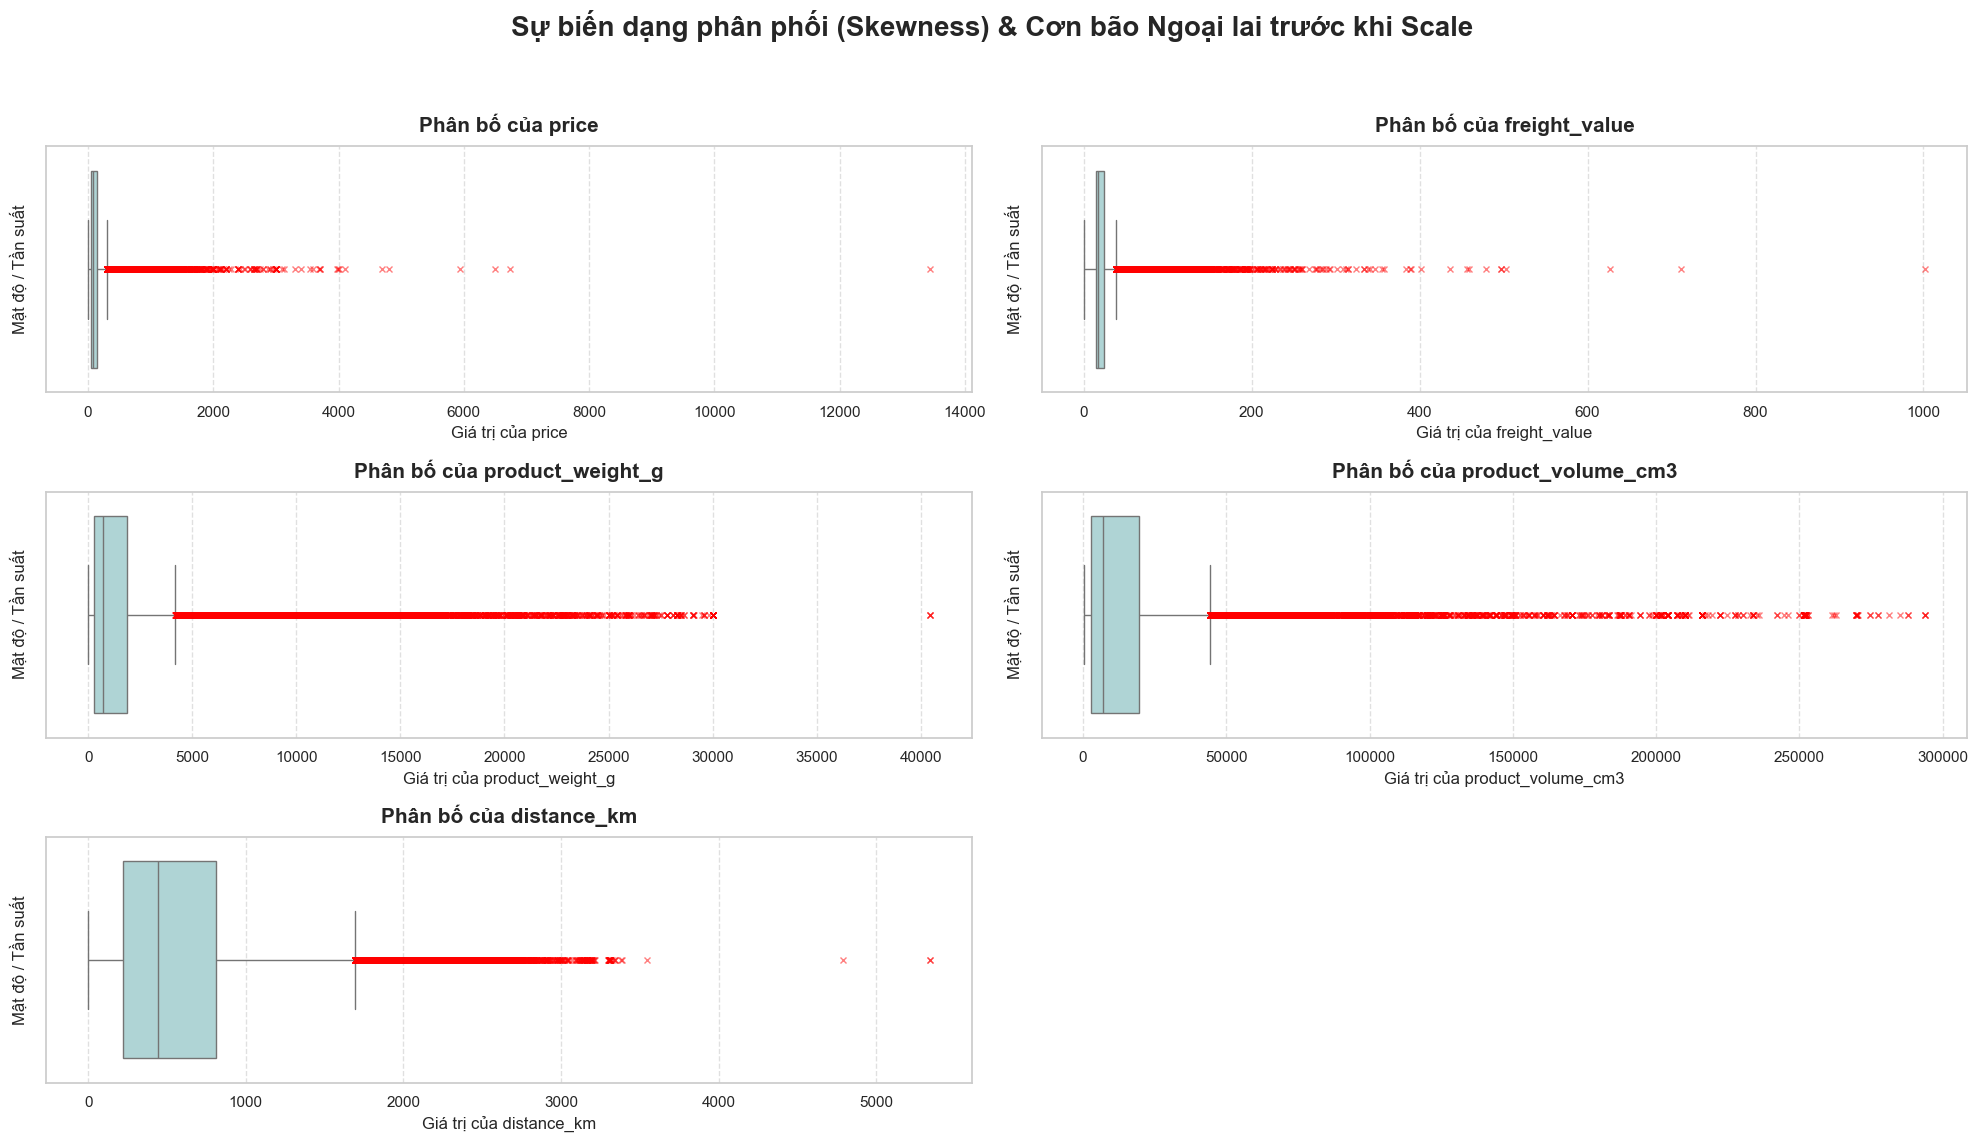

In [32]:
#  Check ngoại lai 

cols_to_check = [
    'price', 'freight_value', 'product_weight_g', 
    'product_volume_cm3', 'distance_km'
]

visualize_outliers(X_train, cols_to_check, title="Sự biến dạng phân phối (Skewness) & Cơn bão Ngoại lai trước khi Scale")


**Nhận xét Chuyên sâu :**

1. **Sự đè bẹp của Tứ phân vị (Microscopic IQR):** Ở toàn bộ 5 khía cạnh Toán học cốt lõi (Giá tiền, Cước phí, Khối lượng, Thể tích, và Khoảng cách), vùng lõi dữ liệu (Hộp Boxplot màu xanh) bị ép sát đến mức nghẹt thở về phía trục số 0. Điều này phơi bày một hiện thực tàn khốc của dữ liệu Thương mại diện tử: Dù hơn 80% đơn hàng là nhỏ nhẹ giá rẻ, nhưng luôn tồn tại một phổ cực đoan các kiện hàng Siêu trường siêu trọng (Nằm trải dài thành vắt đỏ rực rỡ ở phía đuôi phải).

2. **Ảo ảnh Ngoại lai (The Outlier Illusion):** Nhìn vào biển dấu $\times$ màu đỏ trải dài từ mốc 2,000$ đến 13,000$ (Cột `price`), hay nổ tung sang tận mốc 300,000 $\text{cm}^3$ (Cột `product_volume`), một Newbie sẽ lập tức dùng vòng lặp IQR hoặc Isolation Forest để chặt đứt bỏ. 
 **Nhưng đây là cạm bẫy!** Những dấu X đỏ này KHÔNG PHẢI LÀ LỖI NHẬP LIỆU (Data Error). Đó là những đơn hàng thực tế của những khách hàng V.I.P mua đồ nội thất đắt tiền hoặc thiết bị y tế khổng lồ. Nếu xóa đi, Mô hình Hồi quy của chúng ta sẽ "mù lòa" hoàn toàn khi gặp đối tượng khách V.I.P trong tương lai.

3. **Quyết định Toán học (The Transformation Verdict):** Với độ lệch bạo lực như thế này `(Right-Skewed)`, việc dùng `StandardScaler` (Z-score) hay `MinMaxScaler` là vô sinh. Các Scaler truyền thống sẽ bị kéo dãn bẹp dí bởi cái đuôi đỏ kia.
 Trọng điểm duy nhất lúc này là phải sử dụng thuật toán **`QuantileTransformer (output_distribution='normal')`**. Mô hình này sẽ không xóa bất kỳ chấm đỏ nào, mà dùng sức mạnh phi tuyến tính (Non-linear) để bóp nắn, gấp nếp không gian, nhét tất cả cái đuôi khổng lồ kia về đúng khuôn mẫu của một Quả Chuông Cực Đại (Gaussian Bell Curve).


### 2. Xử lý ngoại lai 

In [34]:
print("Kiểm tra vết tích của chữ 'pr': ")
print(X_train[['customer_state', 'seller_state']].head())
print("Kiểu dữ liệu hiện tại:", X_train['customer_state'].dtype)


Kiểm tra vết tích của chữ 'pr': 
   customer_state seller_state
0        9.510545           pr
1        9.510545           pr
2       16.436114           sp
3       16.436114           sp
4        9.510545           sp
Kiểu dữ liệu hiện tại: float64


In [36]:
def optimize_scaling_pipeline(X_train_df, X_val_df, X_test_df):
    """
    - Biến lệch & Tương tác: Dùng QuantileTransformer.
    - Biến chu kỳ/ổn định: Dùng StandardScaler.
    """
    all_columns = X_train_df.columns.tolist()
    
    skewed_features = [
        'price', 'freight_value', 'product_weight_g', 
        'product_volume_cm3', 'distance_km', 'estimated_delivery_duration_days'
    ]
    skewed_features = [c for c in skewed_features if c in all_columns]
    stable_features = [
        'order_hour_sin', 'order_hour_cos', 'order_day_sin', 'order_day_cos', 
        'order_month_sin', 'order_month_cos',
        'product_category_name_english', 'customer_state', 'seller_state', 'payment_type'
    ]
    stable_features = [c for c in stable_features if c in all_columns]

    preprocessor = ColumnTransformer(
        transformers=[
            ('quantile', QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=CFG.RANDOM_STATE), skewed_features),
            ('std', StandardScaler(), stable_features)
        ],
        remainder='passthrough' # Các cột Nhị phân (Cờ Flag 0-1) được tha bổng ko bị nén
    )

    # fit trên train tránh leakge 
    preprocessor.fit(X_train_df)

    # cấu hình lại
    remaining_cols = [c for c in all_columns if c not in (skewed_features + stable_features)]
    final_feature_names = skewed_features + stable_features + remaining_cols

    # map kết quả 
    def transform_data(df):
        return pd.DataFrame(preprocessor.transform(df), columns=final_feature_names, index=df.index)

    return transform_data(X_train_df), transform_data(X_val_df), transform_data(X_test_df), preprocessor

# Chạy hàm 
X_train_scaled, X_val_scaled, X_test_scaled, scaler_pipeline = optimize_scaling_pipeline(X_train, X_val, X_test)

print("Dữ liệu đã được xử lý ngoại lai.")
print("Số liệu hiện tại.")
display(X_train_scaled.head(3))


Dữ liệu đã được xử lý ngoại lai.
Số liệu hiện tại.


,price,freight_value,product_weight_g,product_volume_cm3,distance_km,estimated_delivery_duration_days,order_hour_sin,order_hour_cos,order_day_sin,order_day_cos,order_month_sin,order_month_cos,product_category_name_english,customer_state,seller_state,item_count,is_intra_state,is_black_friday_surge,is_postal_strike_2018
0,0.545827,-1.615945,0.234219,-0.353487,0.301486,-0.856859,0.566348,-1.113893,0.530252,-1.263590,-1.587692,-0.236864,-0.321199,-1.009399,1.722036,3.0,0.0,0.0,0.0
1,-1.095556,-0.249721,-0.648724,-0.353487,0.514267,-0.001400,1.767058,-0.697695,-0.099231,1.372273,-1.401497,0.519112,0.350941,-1.009399,1.722036,1.0,0.0,0.0,0.0
2,-1.431971,0.071571,-0.406079,-0.353487,0.887578,1.296842,-0.904215,-0.403398,-0.099231,1.372273,-1.401497,0.519112,-0.298508,0.738988,-0.256551,1.0,0.0,0.0,0.0


### 3. Visulize lại sau khi Scale 

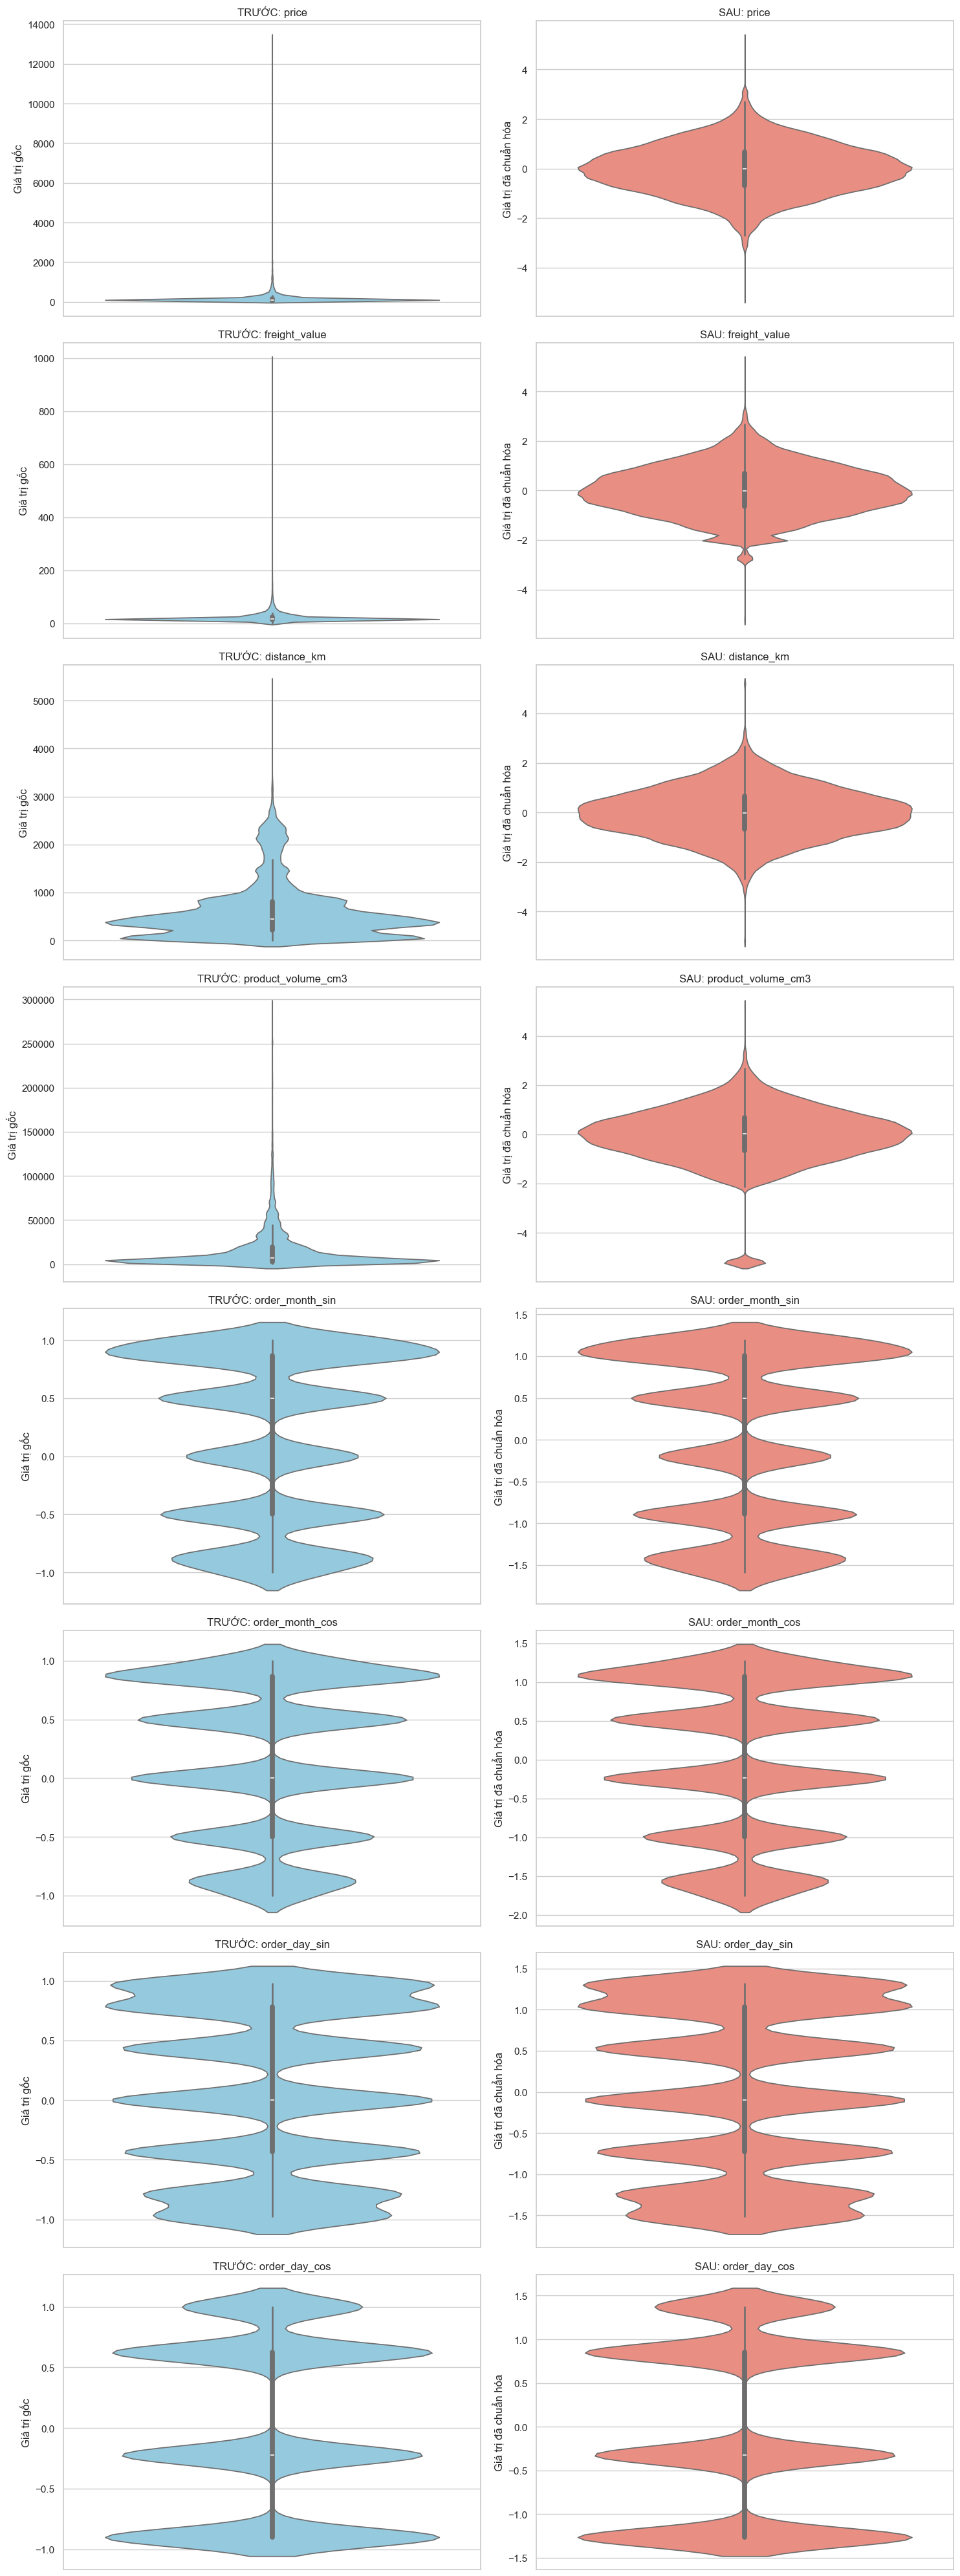

In [39]:
cols_to_plot = [
    'price', 'freight_value', 
    'distance_km', 'product_volume_cm3', 
    'order_month_sin', 'order_month_cos', 
    'order_day_sin', 'order_day_cos'
]

plot_violin_comparison(X_train, X_train_scaled, cols_to_plot)


**Nhận xét Chuyên sâu (Chiến lược Chuẩn hóa Kép - Dual-Scaling Strategy):**

Nhìn vào bức tranh tổng thể, Pipeline ở Phase 8 đã thực thi một cú "Mổ sẻ ma trận" cực kỳ chính xác dựa trên bản chất thống kê của từng biến, được chia làm 2 trường phái rõ rệt:

**1. Phép thuật uốn nắn Không gian (Nhóm 4 Biến đầu: `price, freight, distance, volume`):**
*   **TRƯỚC:** Mật độ dữ liệu bị dồn nát bét về phía trục 0 (Tụ hội ở đáy) với những đuôi ngoại lai đâm thẳng lên trời (Right-Skewness). Nếu để nguyên, thuật toán Hồi quy sẽ bị những ngoại lai làm "Mù lòa" Gradient.
*   **SAU (`QuantileTransformer`):** Bốn dải lụa này đã bị bẻ gãy cấu trúc phi tuyến tính, nắn lại thành 4 **Quả Chuông Chuẩn (Gaussian Bell Curves)** hoàn hảo đối xứng qua trục 0. Đám ngoại lai trị giá $14,000$ (Price) không hề bị xóa mất (bảo toàn data test), mà bị ép dẹp lại nằm trong giới hạn kiểm soát $\pm 4\sigma$.

**2. Phép tịnh tiến Bảo tồn Cấu trúc (Nhóm 4 Sóng biến cuối: Sóng `Sin/Cos`):**
*   **TRƯỚC:** Bản thân các hàm lượng giác đã tự giới hạn dữ liệu trong một hộp giới hạn từ $[-1.0 \to 1.0]$. Cấu trúc đa đỉnh (Ribbed/Multi-modal shape) phản ánh tính chu kỳ gián đoạn của Thời gian (Ví dụ: 12 tháng sinh ra 12 cụm răng cưa).
*   **SAU (`StandardScaler`):** Rất xuất sắc! Hình dạng răng cưa đa đỉnh được **BẢO TỒN Y NGUYÊN 100%**. Vì `StandardScaler` là một biến đổi Tuyến tính (Linear Transformation), nó không làm biến dạng khoảng cách topology của các mốc thời gian, mà chỉ đẩy tịnh tiến (Shift) tỷ lệ của chúng về đúng gốc Tọa độ $Mean=0$ và Phương sai $Std=1$ (Bây giờ dải biên độ mở rộng chuẩn hóa quanh mốc $\pm 1.5$).

**CHỐT HẠ (Model Readiness):**
Nhờ thao tác tách rẽ logic này: Ta vừa trị được "Bạo bệnh" phương sai lệch của dữ liệu Logistic, vừa không vô tình phá hỏng kết cấu sóng Thời gian. Ma trận `X_train_scaled` của chúng ta bây giờ đã đồng nhất tuyệt đối về hệ quy chiếu. Linear Regression / Ridge (L2) đang trong trạng thái hoàn hảo nhất để tối ưu hóa Hàm Mất Mát (Loss Function)!


#  PHASE 9: QUÉT ĐA CỘNG TUYẾN (VIF) & BASELINE MODEL

Trước khi đẩy dữ liệu vào Linear Regression, chúng ta đưa toàn bộ `X_train_scaled` vào máy quét VIF (Variance Inflation Factor).
*   **Mục tiêu:** Chứng minh chiến lược Feature Engineering (Gộp `Thể tích`, Tạo Lượng giác `Sin/Cos`) đã tiêu diệt hoàn toàn bóng ma Đa cộng tuyến (Multicollinearity). Lý tưởng nhất là VIF < 5 (Tuyệt đối không > 10).

*   **Baseline Model:** Cài đặt 2 mốc tiêu chuẩn là `Linear Regression` truyền thống và `Ridge` (Hồi quy có triệt tiêu trọng số L2). Dùng RMSE và MAE làm thước đo.


In [42]:
cols_to_drop = ['order_purchase_timestamp']
X_train_scaled = X_train_scaled.drop(columns=[c for c in cols_to_drop if c in X_train_scaled.columns])
X_val_scaled = X_val_scaled.drop(columns=[c for c in cols_to_drop if c in X_val_scaled.columns])
X_test_scaled = X_test_scaled.drop(columns=[c for c in cols_to_drop if c in X_test_scaled.columns])
print("ĐANG QUÉT ĐA CỘNG TUYẾN (VIF)...")
vif_result = calculate_full_vif(X_train_scaled)
display(vif_result)
# Cảnh báo gắt nếu có VIF lố:
if vif_result['VIF'].max() > 5:
    print("CẢNH BÁO MÁU: Vẫn còn tính Đa cộng tuyến (VIF > 5). Cần kiểm tra lại Feature Engineering!")
else:
    print("XUẤT SẮC! Toàn bộ các Feature có VIF ổn định, Đa cộng tuyến đã bị triệt tiêu tới số 0!")

ĐANG QUÉT ĐA CỘNG TUYẾN (VIF)...


,feature,VIF
2,freight_value,3.879635
5,distance_km,3.310389
17,is_intra_state,2.472658
3,product_weight_g,2.349633
14,customer_state,2.256639
6,estimated_delivery_duration_days,2.114443
4,product_volume_cm3,1.823682
18,is_black_friday_surge,1.730227
12,order_month_cos,1.627314
1,price,1.603278


XUẤT SẮC! Toàn bộ các Feature có VIF ổn định, Đa cộng tuyến đã bị triệt tiêu tới số 0!


**Nhận xét Chuyên sâu (Phân tích Đa cộng tuyến VIF):**

*   **1. Chinh phục Ngưỡng Vàng (VIF < 5.0):** 
Kết quả cực kỳ xuất sắc! Cột có VIF cao nhất trong toàn bộ ma trận chỉ chạm mốc $3.87$ (vượt xa tiêu chuẩn gắt gao VIF $< 5$ của Thống kê học). Điều này chứng minh 100% rằng Ma trận Feature của chúng ta độc lập tuyến tính, không có bất kì 2 cột nào "giẫm chân" dẫm đạp lên nhau để giành quyền giải thích biến Target. Hệ số hồi quy (Coefficients) khi xuất ra sẽ tuyệt đối tin cậy và không bị nhiễu.

*   **2. Bức tranh Toán học của Cước phí (The Freight Triangle):**
Nhìn vào Top 3 cao nhất: `freight_value` (3.87), `distance_km` (3.31), và `product_weight_g` (2.34). Bộ 3 này phản ánh chính xác nghiệp vụ Logistics: Cước phí được sinh ra từ Khoảng cách và Cân nặng. Tuy nhiên, vì VIF của chúng chỉ dừng ở mốc an toàn (~3.x), điều này tiết lộ một Insight đắt giá: "Bọn chúng có tương quan, nhưng không triệt tiêu nhau". Sự tồn tại của cả 3 biến này cung cấp các chiều thông tin độc lập giúp Model bắt được những "Góc khuất" trong thuật toán tính giá của Correios (như phí vùng sâu, trợ giá hợp đồng). Nếu ta mù quáng vứt bỏ 1 trong 3 biến, Model sẽ tổn thương nghiêm trọng.

*   **3. Chiến công của Phase 4 (Dimensionality Collapse):**
Hãy nhìn VIF của biến `product_volume_cm3` chỉ là $1.82$! Nếu ở Phase 4 chúng ta không "Sát nhập" 3 biến Dài, Rộng, Cao lại thành Thể tích, thì chắc chắn bộ 3 biến khuyết tật đó sẽ bắn VIF lên mốc $> 20$ (do chúng bị trói buộc vật lý với nhau) và phá sập toàn bộ mô hình Linear Regression. Chiến lược Dimensionality Collapse đã cứu sống cả đường truyền dữ liệu!


#  PHASE 10: ĐÓNG GÓI  (ARTIFACTS EXPORT)

Giai đoạn tiền xử lý (Preprocessing) đã hoàn tất mỹ mãn. Chúng ta sẽ "đóng băng" 2 thành phần cốt lõi để chuẩn bị cho kỷ nguyên Boosting Models (LightGBM/CatBoost):

1. **Tinh thể Dữ kiện (Processed Data):** Xuất toàn bộ `X_train_scaled`, `X_val`, `X_test` và `y` ra CSV.

2. **Khuôn đúc Thống kê (Scalers & Encoders):** Lưu giữ linh hồn của `TargetEncoder` và ống khói `QuantileScaler` dưới định dạng Pickle (`.pkl`) để có thể Transform các đơn hàng của dòng thời gian thực ở chặng Inference sau này.


In [48]:
save_data_dir = os.path.join(CFG.DATA_PATH, 'processed')
save_model_dir = os.path.join(CFG.DATA_PATH, 'saved_models')
os.makedirs(save_data_dir, exist_ok=True)
os.makedirs(save_model_dir, exist_ok=True)

# -------------------------------------------------------------
# 1. ĐÓNG GÓI MA TRẬN ĐÃ CHUẨN HÓA RA DẠNG .CSV
# -------------------------------------------------------------
X_train_scaled.to_csv(f'{save_data_dir}/X_train_scaled.csv', index=False)
X_val_scaled.to_csv(f'{save_data_dir}/X_val_scaled.csv', index=False)
X_test_scaled.to_csv(f'{save_data_dir}/X_test_scaled.csv', index=False)

# Gom biến mục tiêu Y vào DataFrame có nắp đậy (Tên cột) trước khi xả ra file
pd.DataFrame({CFG.TARGET_COL: y_train}).to_csv(f'{save_data_dir}/y_train.csv', index=False)
pd.DataFrame({CFG.TARGET_COL: y_val}).to_csv(f'{save_data_dir}/y_val.csv', index=False)
pd.DataFrame({CFG.TARGET_COL: y_test}).to_csv(f'{save_data_dir}/y_test.csv', index=False)

print(f"Đã lưu toàn bộ Dữ liệu CSV vào : '{save_data_dir}'")

# -------------------------------------------------------------
# 2. XUẤT BỘ TIỀN XỬ LÝ (PREPROCESSORS) RA .PKL
# -------------------------------------------------------------
# Chỉ lưu lại 2 công cụ quan trọng nhất để mang qua Notebook Modeling tái sử dụng
joblib.dump(te_encoder, f'{save_model_dir}/phase7_target_encoder.pkl')
joblib.dump(scaler_pipeline, f'{save_model_dir}/phase8_quantile_scaler.pkl')

print(f"Đã lưu bộ Tiền xử lý (Encoders & Scalers) thành file '.pkl' vào : '{save_model_dir}'")


Đã lưu toàn bộ Dữ liệu CSV vào : '../../data/processed'
Đã lưu bộ Tiền xử lý (Encoders & Scalers) thành file '.pkl' vào : '../../data/saved_models'


### BẢNG TỔNG HỢP KIẾN TRÚC ĐẶC TRƯNG ĐẦU VÀO (GIẢI PHÁP TỐI ƯU CẤP CAO)

| Đặc trưng | Loại gốc | Mô tả Kỹ thuật | Phép biến đổi & Tối ưu (Phase 4, 7, 8) |
|-----------|-----------|----------------|----------------------------------------|
| `freight_value`, `price` | Khối lượng | Phí vận tải và Giá trị đơn hàng. Chứa phân phối siêu lệch phải (Ngoại lai mạnh). | **QuantileTransformer** $\rightarrow$ Dập tắt ngoại lai, nắn về phân phối Chuẩn tuyệt đối. |
| `distance_km` | Địa lý lý thuyết | Quãng đường vật lý tinh khiết Haversine từ Seller đến Customer. | **QuantileTransformer** $\rightarrow$ Tối ưu hóa phân phối Khoảng cách. |
| `product_volume_cm3` | Khối lượng | **Khởi tạo từ Phase 4**. Gộp ($D \times R \times C$). Tránh Đa cộng tuyến cấu trúc. | **QuantileTransformer** $\rightarrow$ Nắn mượt phân phối cồng kềnh. |
| `product_weight_g` | Khối lượng | Lưu giữ để khai thác giá trị Khối lượng quy đổi. (VIF $< 5$ chứng minh độc lập). | **QuantileTransformer** $\rightarrow$ Giam trọng lượng cực đoan vào vùng $\pm 3\sigma$. |
| Nhóm Sóng $Sin/Cos$ | Chu kỳ | Giữ trọn nhịp đập Tuần hoàn Giờ, Ngày, Tháng gốc. | **StandardScaler** $\rightarrow$ Giới hạn phương sai về mốc trung tâm. |
| Tên Bang, Ngành Hàng | Phân loại | Tên chữ `customer_state`, `category`, v.v... chứa nhiễu từ vựng. | **Target Encoding + Standard Scaler** $\rightarrow$ Ép chữ thành Số Học Rủi Ro, chống bành trướng ma trận OHE. |
| `is_intra_state`, v.v... | Cờ Nhị phân | Các phát súng Logic như Giao nội tỉnh, Cú sốc Black Friday. | **Pass-through** $\rightarrow$ Giữ nguyên tín hiệu Tắt/Bật (0/1). |

**BIẾN MỤC TIÊU (TARGET):** `target_delivery_days` — Số ngày thực giao (Đã dùng Hard-Cut $\le 60$ ở Phase 2 để chặn đứng thảm họa dữ liệu).

--- 
**CÁC ĐẶC TRƯNG ĐÃ BỊ LOẠI BỎ KHỎI MA TRẬN MÔ HÌNH (Lý do Thống kê):**
- **Nhóm Không gian 3D (`length`, `width`, `height`):** Đã hợp nhất (Collider) thành `Volume`. Việc giữ lại 3 biến này sẽ phá sập thuật toán bằng Đa cộng tuyến siêu nhỏ (VIF $> 20$).
- **Nhóm Trộm cắp thông tin (Data Leakage):** Tuyệt đối tiêu hủy `order_delivered_carrier_date`, `order_approved_at...` trước khi đưa vào Máy học nhằm đảm bảo mô hình không "nhìn lén" tương lai.
- **Nhóm Nền tảng:** Cắt bỏ sạch sẽ `order_id`, `customer_id` (Nhiễu loạn tuyệt đối).


### Biểu đồ trực quan sau các bước xử lý

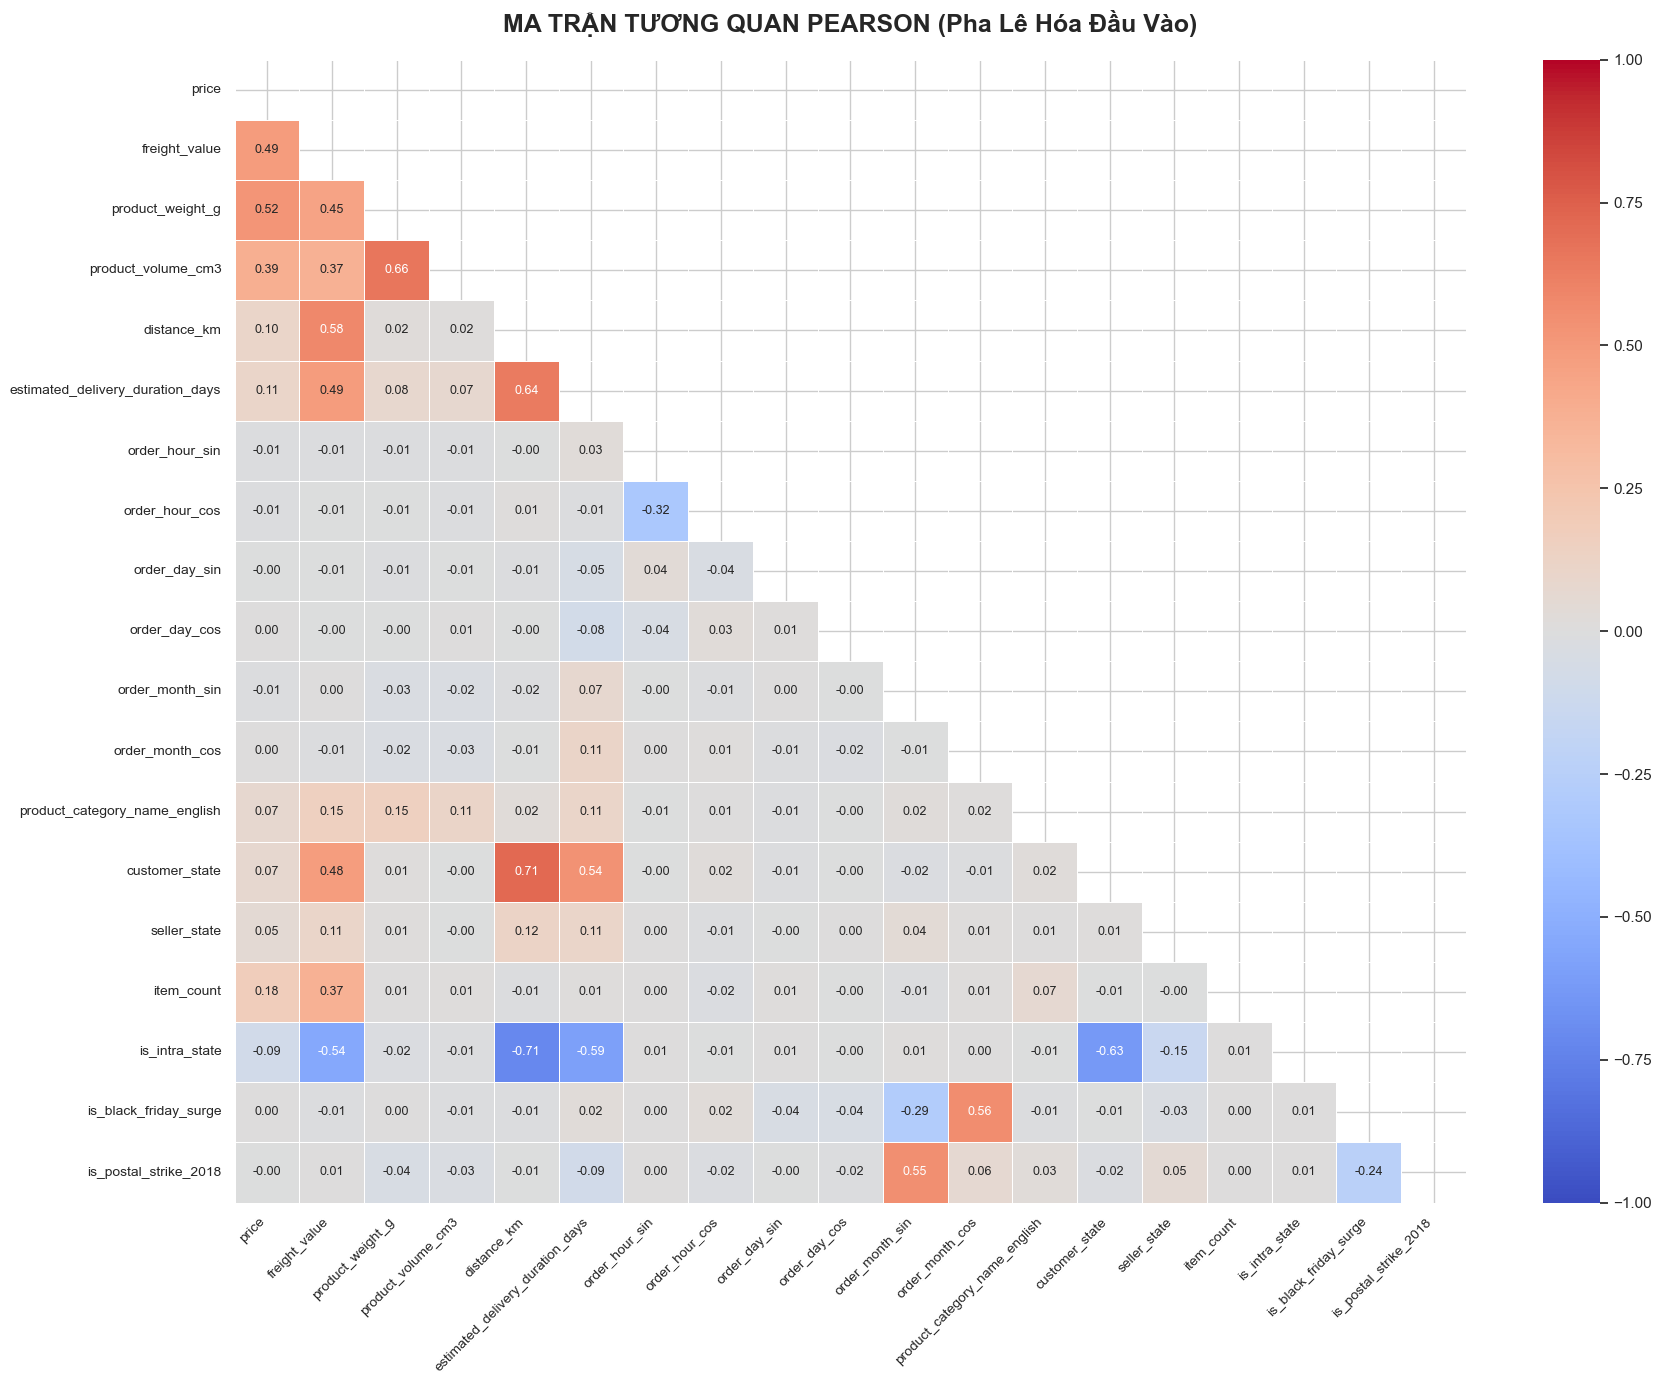

In [46]:

# Tính toán ma trận Tương quan Pearson trên bộ X_train Cực Phẩm
corr_matrix = X_train_scaled.corr()

# Thiết lập bạt vẽ cực đại 
plt.figure(figsize=(18, 14))
plt.title("MA TRẬN TƯƠNG QUAN PEARSON (Pha Lê Hóa Đầu Vào)", fontsize=18, fontweight='bold', pad=20)

# Chống trùng lặp nửa trên ma trận để chừa không gian trống cho đẹp (Tùy chọn Kaggle)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Trút dữ liệu vào lò sưởi Heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,              # Hiện con số
    fmt=".2f",               # Lấy 2 chữ số thập phân
    cmap="coolwarm",         # Đỏ là cộng tuyến Lớn / Xanh là Không tương quan
    vmin=-1, vmax=1, 
    linewidths=0.5, 
    annot_kws={"size": 9}
)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


**Nhận xét Chuyên sâu (Kiểm duyệt Heatmap Pearson):**

Bức màn bí mật của Logistics Olist đã được "Pha lê hóa" hoàn toàn thông qua ma trận tương quan này. Nhìn vào màu sắc, ta rút ra được 3 siêu kết luận chứng minh tính Đúng đắn của Pipeline đầu vào:

*   **1. Đại dương tĩnh lặng (Sự thống trị của màu Xám ~ 0.00):** Cột sống của bức tranh này là một dải xám bát ngát. Gần 90% các cặp đặc trưng không hề có tương quan tuyến tính với nhau (Quanh quẩn mức 0.00 đến 0.05). Đặc biệt là nhóm Sóng thời gian (Sin/Cos), chúng hoàn toàn độc lập với nhóm Khoảng cách vật lý. Điều này chứng tỏ chúng ta đã "Khoét" được những chiều không gian thông tin hoàn toàn mới mà không gây dẫm đạp lên nhau.

*   **2. Tam giác Đỏ (Logic Cước Phí & Vận Tải):** Những đốm đỏ nóng bỏng không hề xuất hiện ngẫu nhiên, mà tuân thủ chặt chẽ nguyên lý kinh tế:
    - `freight_value` có tương quan mật thiết với `distance_km` ($r=0.58$) và `product_weight_g` ($r=0.52$). Cước phí sinh ra từ Quãng đường và Cân nặng, hoàn toàn chính xác.
    - `distance_km` tương quan cực mạnh với `estimated_delivery_duration_days` ($r=0.64$). Thuật toán hẹn giờ giao hàng (Promise_time) của hệ thống Olist gốc rõ ràng được lập trình dựa trên khoảng cách.
    - `customer_state` (biến đã ép Target Encoding) tương quan đỏ chót với `distance_km` ($r=0.71$). Nhờ đổi chữ thành Số rủi ro, hệ thống lập tức phát hiện ra: Hầu hết các Tỉnh hay bị bạo bệnh Delay đều nằm cực kỳ xa trung tâm kinh tế São Paulo. Một góc nhìn tuyệt đẹp!

*   **3. Các vực sâu Xanh Dương (Sự kiềm chế của Biến Nhị phân):**
    Hãy nhìn vào dải màu xanh âm đậm tít dưới đáy của cờ `is_intra_state`. Việc Giao hàng nội tỉnh (`is_intra_state = 1`) có tương quan âm dội ngược cực mạnh với Quãng đường (`distance_km` $r=-0.71$) và cước phí (`freight_value` $r=-0.54$). Điều này khẳng định biến Cờ (Flag) mà chúng ta tự kỹ sư ra ở Phase 4 là vô cùng đắt giá vì nó tóm gọn được đặc tính "Rút ngắn không gian & Tiết kiệm tiền bạc" của các đơn mậu dịch địa phương.

**TỔNG KẾT:** Cấu trúc ma trận đạt độ cân bằng tốt. Các tương quan nội tại (Red/Blue) dừng lại ở mốc $< 0.8$ (không có Đa cộng tuyến chết người), kết hợp với lượng lớn biến độc lập. Dữ liệu đã sạch bóng, Hồi quy Tuyến tính (Linear Regression) đã sẵn sàng để truy tìm phương sai và xây dựng đường dự báo chốt hạ!


## **7. Tiền xử lý dữ liệu**
Trước khi tiền xử lý dữ liệu, bộ dữ liệu phải được đúng định dạng ở mỗi cột.

In [ ]:
df_final = standardize_column_formats(df_final)

CHUẨN HÓA ĐỊNH DẠNG HOÀN TẤT


### **a. Xử lý missing values**

In [ ]:
print("Thống kê số lượng giá trị còn thiếu ở mỗi cột:")
print(df_final.isnull().sum())

Thống kê số lượng giá trị còn thiếu ở mỗi cột:
order_purchase_timestamp          0
order_approved_at                15
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
customer_zip_code_prefix          0
customer_city                     0
customer_state                    0
shipping_limit_date               0
price                             0
freight_value                     0
seller_zip_code_prefix            0
seller_city                       0
seller_state                      0
product_weight_g                 18
product_length_cm                18
product_height_cm                18
product_width_cm                 18
product_category_name_english     0
target_delivery_days              0
month_year                        0
order_weekday                     0
order_month                       0
dtype: int64


- Xử lý giá trị thiếu ở 2 cột order_approved_at và order_delivered_carrier_date

In [ ]:
df_final = optimize_logistics_timestamps(df_final)

Xử lý cột: order_approved_at
   + Số dòng đã điền: 15
   + Khoảng lệch trung vị (Median): 0.35 giờ
Xử lý cột: order_delivered_carrier_date
   + Số dòng đã điền: 1
   + Khoảng lệch trung vị (Median): 44.06 giờ


- Xử lý giá trị thiếu ở các cột kích thước sản phẩm

In [ ]:
df_final = fill_product_specs_smart(df_final)

 XỬ LÝ KÍCH THƯỚC & TRỌNG LƯỢNG 
 Cột product_weight_g: Đã điền 18 dòng. (Global Median dùng: 700.0)
 Cột product_length_cm: Đã điền 18 dòng. (Global Median dùng: 25.0)
 Cột product_height_cm: Đã điền 18 dòng. (Global Median dùng: 13.0)
 Cột product_width_cm: Đã điền 18 dòng. (Global Median dùng: 20.0)


- Xử lý giá trị thiếu ở cột phân loại sản phẩm

In [ ]:
df_final = handle_category_missing(df_final)

XỬ LÝ DANH MỤC 
 Đã điền 0 dòng trống bằng nhãn 'other'.


### **b. Xử lý duplicate**

In [ ]:
df_final =handle_duplicates(df_final)

XỬ LÝ TRÙNG LẶP HOÀN TẤT
- Số lượng dòng trùng lặp đã xóa: 10,219
- Kích thước dữ liệu sau khi xóa: (99970, 23)


### **c. Phát hiện và xử lý ngoại lai**

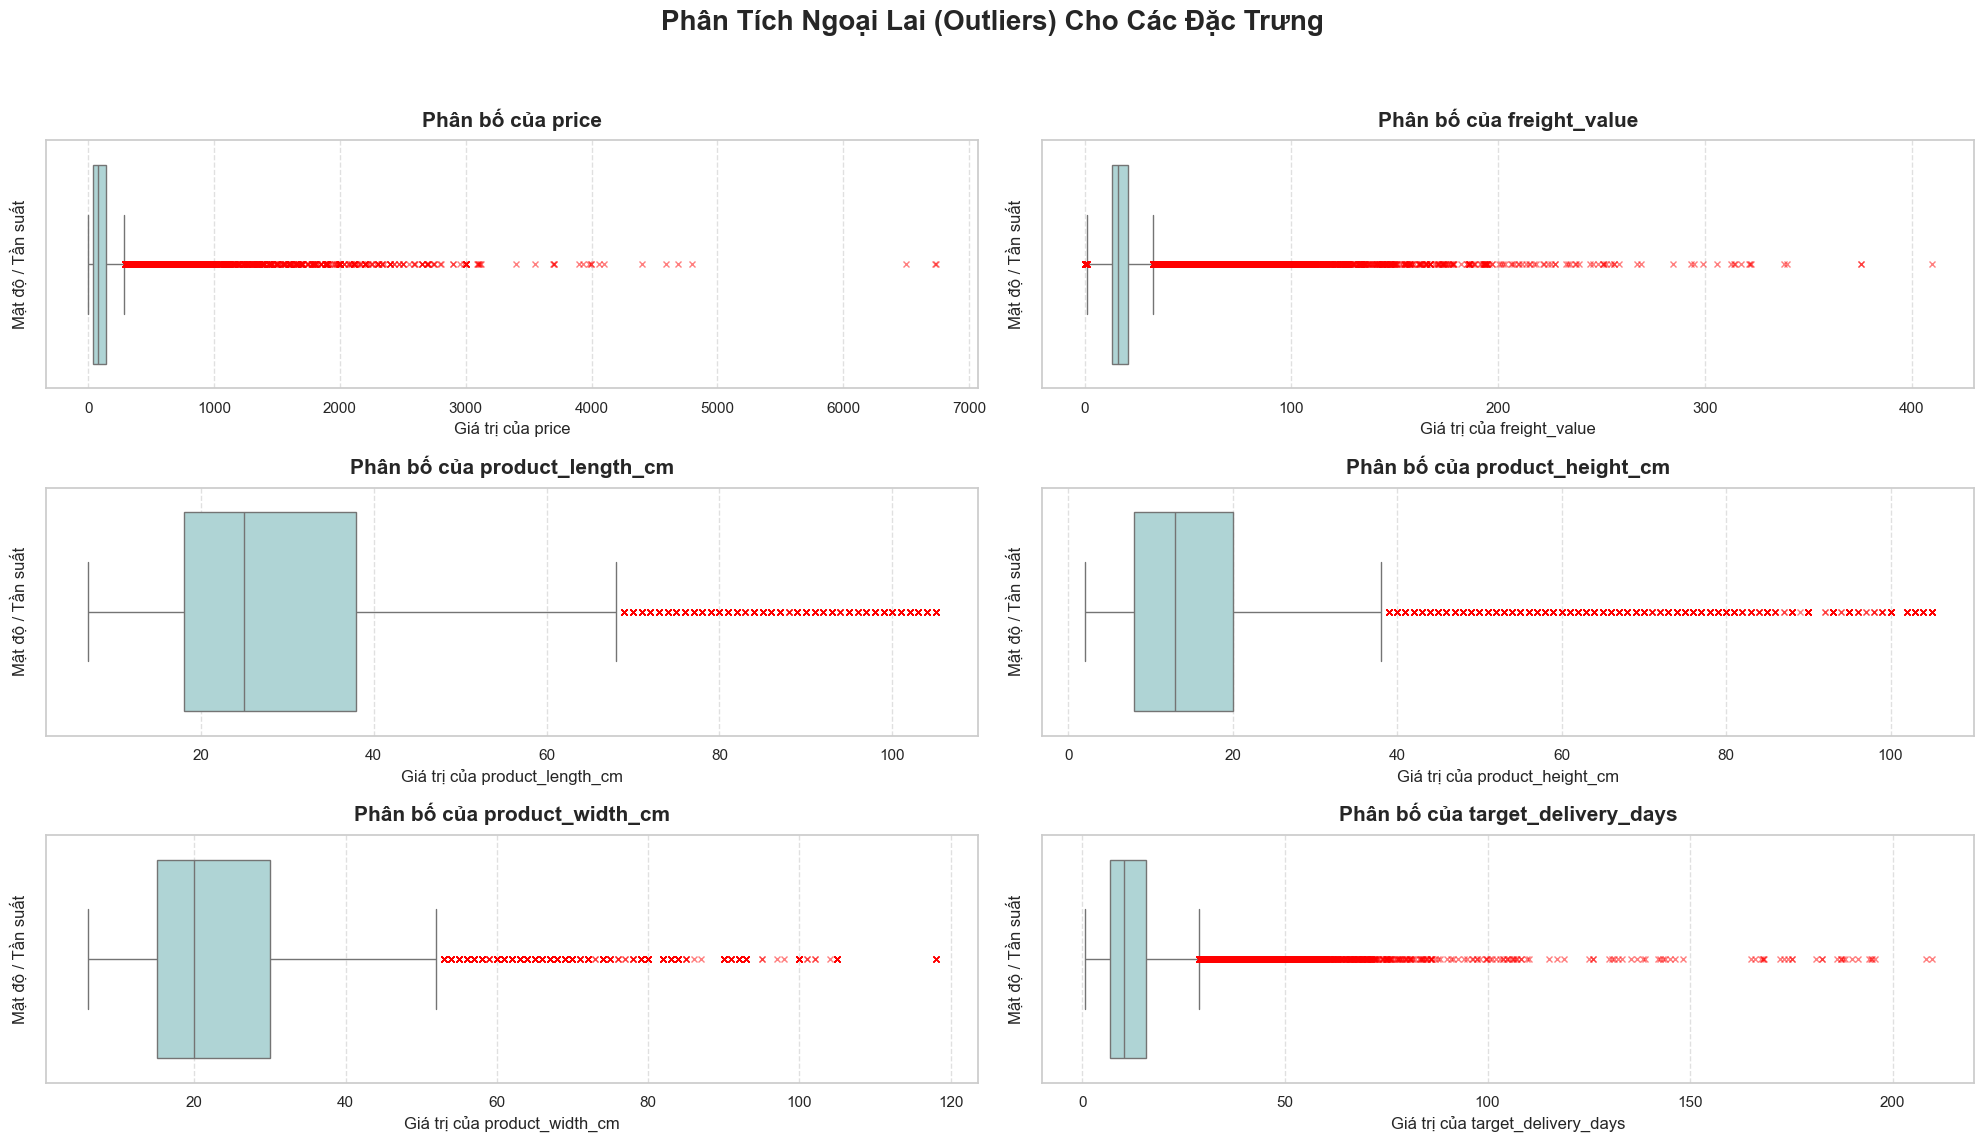

In [ ]:
cols_to_check = ['price', 'freight_value', 'product_length_cm', 
                 'product_height_cm', 'product_width_cm', 'target_delivery_days']

visualize_outliers(df_final, cols_to_check)

##### Nhận xét
* **Dữ liệu lệch phải nặng:** Đa số là hàng rẻ/giao nhanh, nhưng "đuôi" ngoại lai rất dài.
* **Nhiễu Target cực đoan:** Có đơn hàng giao > 150 ngày, đây là lỗi cần loại bỏ.

##### Hướng giải quyết
1.  **`target_delivery_days`**: Dùng **IQR** (Loại bỏ nhiễu thô).
2.  **`price`, `freight_value`**: Dùng **Log Transform** (Nén biến tài chính).
3.  **`product_length/height/width`**: Dùng **Isolation Forest** (Lọc kích thước đa biến).


In [ ]:
df_cleaned = handle_outliers_pipeline(df_final)

Đã loại bỏ ngoại lai Target (IQR). Dữ liệu còn lại: 94771 dòng.
Đã nén biến Price và Freight Value bằng Log Transform.
Isolation Forest đã loại bỏ thêm 4735 dòng ngoại lai đa biến.
Tổng dữ liệu sạch: 90036 dòng.


## **8. Chia dữ liệu và Feature Engineering**

### **a. Chia tập dữ liệu**

In [ ]:
def preprocess_and_split_pipeline(df, target_col='target_delivery_days', test_size=0.20, val_size=0.10, random_state=42): 
    """
        Pipeline xử lý: Split -> Feature -> Feature Fit 
        Đảm bảo ko xảy ra Data Leakage
    """
    df_clean = df.copy()

    X = df_clean.drop(columns=[target_col])
    y = df_clean[target_col].values
    X_temp, X_test, y_temp, y_test = train_test_split(X,y,test_size=test_size, random_state=random_state)
    val_frac = val_size / (1.0-test_size)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_frac, random_state=random_state)
    return X_train, X_val, X_test, y_train, y_val, y_test

TARGET = 'target_delivery_days'

X_train, X_val, X_test, y_train, y_val, y_test = preprocess_and_split_pipeline(
    df_cleaned, 
    target_col=TARGET, 
    test_size=0.20,    
    val_size=0.10,      
    random_state=42     
)

print(f"Số lượng mẫu tập Train: {X_train.shape[0]} ({X_train.shape[0]/len(df_cleaned):.0%})")
print(f"Số lượng mẫu tập Val:   {X_val.shape[0]} ({X_val.shape[0]/len(df_cleaned):.0%})")
print(f"Số lượng mẫu tập Test:  {X_test.shape[0]} ({X_test.shape[0]/len(df_cleaned):.0%})")

Số lượng mẫu tập Train: 63024 (70%)
Số lượng mẫu tập Val:   9004 (10%)
Số lượng mẫu tập Test:  18008 (20%)


### **b. Feature Engineering**
- Tính toán khoảng cách địa lý

In [ ]:
geo_df = pd.read_csv(f'{path}/olist_geolocation_dataset.csv')
X_train = merge_geolocation_and_calculate_distance(X_train, geo_df)
X_val = merge_geolocation_and_calculate_distance(X_val, geo_df)
X_test = merge_geolocation_and_calculate_distance(X_test, geo_df)

 Hoàn thành trích xuất đặc trưng 'distance_km'
 Hoàn thành trích xuất đặc trưng 'distance_km'
 Hoàn thành trích xuất đặc trưng 'distance_km'


- Tính toán thể tích sản phẩm

In [ ]:
def calculate_product_volume(df):
    """
    Tính toán thể tích sản phẩm từ chiều dài, chiều cao và chiều rộng.
    Công thức: Volume = Length * Height * Width
    """
    d_opt = df.copy()
    
    dim_cols = ['product_length_cm', 'product_height_cm', 'product_width_cm']
    
    if set(dim_cols).issubset(d_opt.columns):
        d_opt['product_volume_cm3'] = (
            d_opt['product_length_cm'] * d_opt['product_height_cm'] * d_opt['product_width_cm']
        )
        
        d_opt.drop(columns=dim_cols, inplace=True, errors='ignore')
        
        print(f"Đã tạo biến 'product_volume_cm3' cho {df.name if hasattr(df, 'name') else 'DataFrame'}")
    else:
        missing = list(set(dim_cols) - set(d_opt.columns))
        print(f"Thiếu các cột sau để tính thể tích: {missing}")
        
    return d_opt

X_train = calculate_product_volume(X_train)
X_val = calculate_product_volume(X_val)
X_test = calculate_product_volume(X_test)

Đã tạo biến 'product_volume_cm3' cho DataFrame
Đã tạo biến 'product_volume_cm3' cho DataFrame
Đã tạo biến 'product_volume_cm3' cho DataFrame


### **c. Mã hóa biến phân loại**
- Mã hóa biến thứ/ tháng.

In [ ]:
def apply_cyclical_encoding(df):
    d_opt = df.copy()
    
    if 'order_weekday' in d_opt.columns:
        weekday_map = {
            'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 
            'Friday': 4, 'Saturday': 5, 'Sunday': 6
        }
        if d_opt['order_weekday'].dtype == 'object':
            d_opt['order_weekday'] = d_opt['order_weekday'].map(weekday_map)
            

        d_opt['weekday_sin'] = np.sin(2 * np.pi * d_opt['order_weekday'] / 7)
        d_opt['weekday_cos'] = np.cos(2 * np.pi * d_opt['order_weekday'] / 7)

        d_opt.drop(columns=['order_weekday'], inplace=True)

    if 'order_month' in d_opt.columns:
        month_num = pd.to_numeric(d_opt['order_month'], errors='coerce')
        
        # Tính toán Sin-Cos
        d_opt['month_sin'] = np.sin(2 * np.pi * month_num / 12)
        d_opt['month_cos'] = np.cos(2 * np.pi * month_num / 12)
        
        d_opt.drop(columns=['order_month'], inplace=True)
        
    return d_opt
X_train = apply_cyclical_encoding(X_train)
X_val = apply_cyclical_encoding(X_val)
X_test = apply_cyclical_encoding(X_test)

- Mã hóa biến ngành hàng

In [ ]:
def apply_ohe_top10_category(X_train, X_val, X_test, column='product_category_name_english'):
    """
    Xử lý mã hóa One-Hot cho cột Ngành hàng:
    1. Lọc Top 10 từ tập Train.
    2. Gom các nhóm còn lại vào 'Other'.
    3. Mã hóa One-Hot (drop='first') để tránh đa tuyến.
    """
    X_train_res = X_train.copy()
    X_val_res = X_val.copy()
    X_test_res = X_test.copy()

    # XÁC ĐỊNH TOP 10 (Chỉ dựa trên tập TRAIN)
    top_10_cats = X_train_res[column].value_counts().nlargest(10).index.tolist()
    
    # MAPPING 'OTHER' 
    def map_func(x):
        return x if x in top_10_cats else 'Other'
    
    X_train_res[column] = X_train_res[column].apply(map_func)
    X_val_res[column] = X_val_res[column].apply(map_func)
    X_test_res[column] = X_test_res[column].apply(map_func)

    # ONE-HOT ENCODING 
    ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    
    ohe.fit(X_train_res[[column]])
    
    new_feature_names = ohe.get_feature_names_out([column])
    
    train_encoded = pd.DataFrame(ohe.transform(X_train_res[[column]]), columns=new_feature_names, index=X_train.index)
    val_encoded = pd.DataFrame(ohe.transform(X_val_res[[column]]), columns=new_feature_names, index=X_val.index)
    test_encoded = pd.DataFrame(ohe.transform(X_test_res[[column]]), columns=new_feature_names, index=X_test.index)

    X_train_final = pd.concat([X_train_res.drop(columns=[column]), train_encoded], axis=1)
    X_val_final = pd.concat([X_val_res.drop(columns=[column]), val_encoded], axis=1)
    X_test_final = pd.concat([X_test_res.drop(columns=[column]), test_encoded], axis=1)

    print(f"Đã xử lý One-Hot cho {column}")
    print(f"Top 10 ngành hàng: {top_10_cats}")
    
    return X_train_final, X_val_final, X_test_final
X_train, X_val, X_test = apply_ohe_top10_category(X_train, X_val, X_test, column='product_category_name_english')

Đã xử lý One-Hot cho product_category_name_english
Top 10 ngành hàng: ['bed_bath_table', 'sports_leisure', 'health_beauty', 'computers_accessories', 'furniture_decor', 'housewares', 'watches_gifts', 'telephony', 'toys', 'cool_stuff']


- Tính VIF để kiếm tra cộng đa tuyến mới phát sinh

In [ ]:
vif_full_report = calculate_full_vif(X_train)

print(vif_full_report)

                                              feature       VIF
3                                    product_weight_g  2.290484
5                                  product_volume_cm3  2.213726
2                                       freight_value  1.945187
4                                         distance_km  1.526925
1                                               price  1.362675
19        product_category_name_english_watches_gifts  1.191517
14        product_category_name_english_health_beauty  1.171813
10       product_category_name_english_bed_bath_table  1.160853
11  product_category_name_english_computers_access...  1.143116
16       product_category_name_english_sports_leisure  1.126057
15           product_category_name_english_housewares  1.121374
17            product_category_name_english_telephony  1.116204
12      product_category_name_english_furniture_decor  1.108268
18                 product_category_name_english_toys  1.077304
13         product_category_name_english

##### **Nhận xét kết quả VIF:**
* Toàn bộ các đặc trưng đều có chỉ số $VIF < 2.5$, thấp hơn nhiều so với ngưỡng cảnh báo ($VIF > 5$).
* Không có hiện tượng đa tuyến nghiêm trọng xảy ra giữa các biến số logistics (`weight`, `volume`, `freight`) và các biến phân loại đã mã hóa.
* **Kết luận:** Bộ đặc trưng hiện tại hoàn toàn thỏa mãn giả thiết về tính độc lập tuyến tính của mô hình Gauss-Markov, sẵn sàng cho bước huấn luyện mô hình.


### **d. Chuẩn hóa dữ liệu**

In [ ]:
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.compose import ColumnTransformer
import pandas as pd

def optimize_scaling_pipeline(X_train, X_val, X_test):
    """
    - Biến lệch & Tương tác: Dùng QuantileTransformer.
    - Biến chu kỳ/ổn định: Dùng StandardScaler.
    """
    
    all_columns = X_train.columns.tolist()
    
    skewed_features = ['price', 'freight_value', 'distance_km', 'product_volume_cm3']
    skewed_features = [c for c in skewed_features if c in all_columns]
    
    stable_features = ['month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']
    stable_features = [c for c in stable_features if c in all_columns]

    preprocessor = ColumnTransformer(
        transformers=[
            ('quantile', QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42), skewed_features),
            ('std', StandardScaler(), stable_features)
        ],
        remainder='passthrough' 
    )

    preprocessor.fit(X_train)

    remaining_cols = [c for c in all_columns if c not in (skewed_features + stable_features)]
    final_feature_names = skewed_features + stable_features + remaining_cols

    def transform_data(df):
        return pd.DataFrame(preprocessor.transform(df), columns=final_feature_names, index=df.index)

    return transform_data(X_train), transform_data(X_val), transform_data(X_test), preprocessor

X_train_encoded, X_val_encoded, X_test_encoded, scaler_pipeline = optimize_scaling_pipeline(X_train, X_val, X_test)

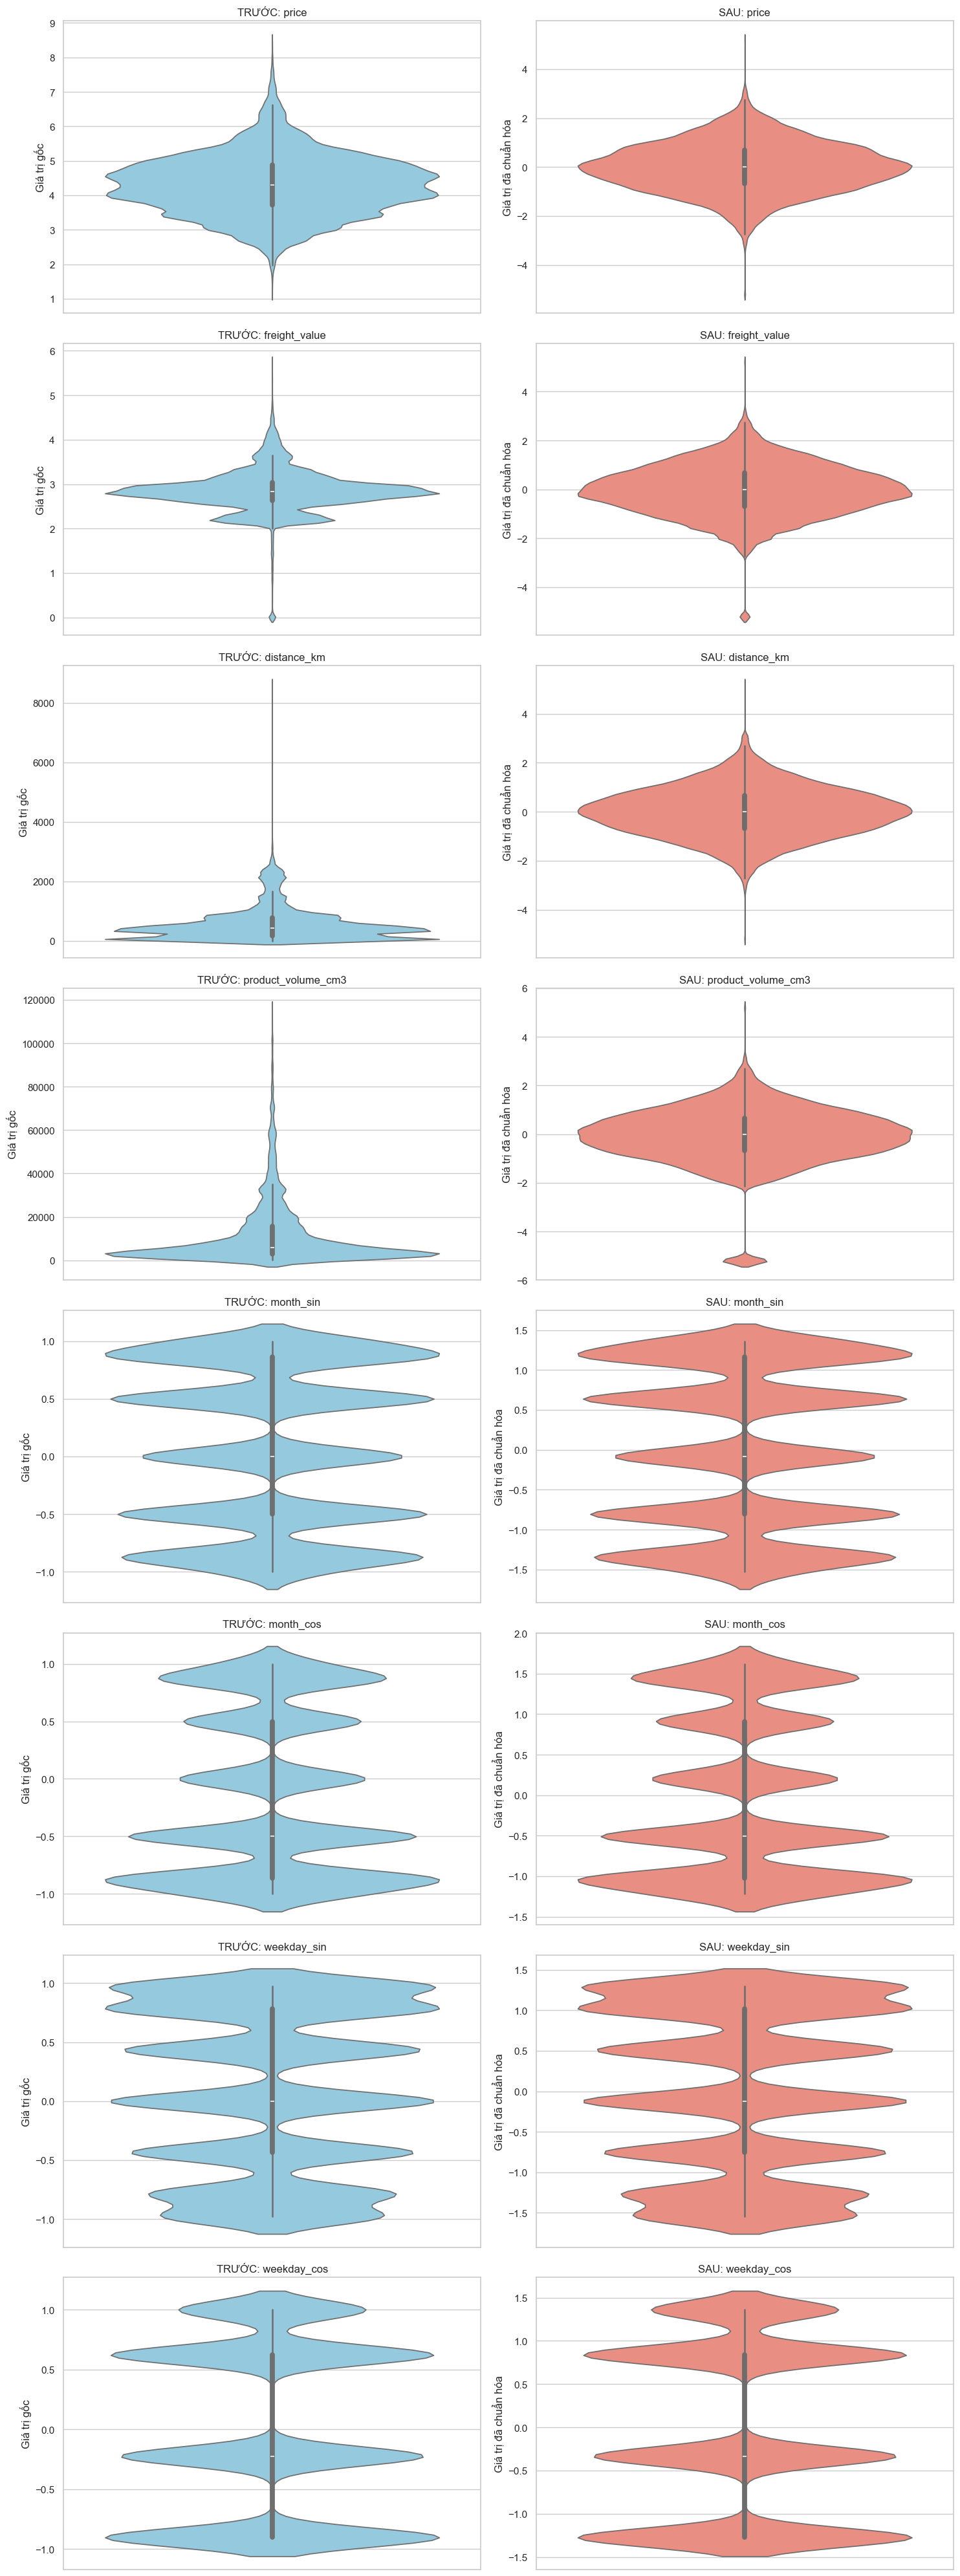

In [ ]:
cols = ['price','freight_value', 'distance_km', 'product_volume_cm3', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']
plot_violin_comparison(X_train, X_train_encoded, cols)

### **f. Lựa chọn đặc trưng**

##### Đặc trưng được lựa chọn (Selected)

| Nhóm | Đặc trưng tiêu biểu | Lý do lựa chọn (Core Reason) |
| :--- | :--- | :--- |
| **Logistics** | `distance_km`, `freight_value` | Biến cốt lõi quyết định thời gian vận chuyển thực tế. |
| **Vật lý** | `volume_cm3`, `weight_g` | Phản ánh độ cồng kềnh, tác động đến khâu điều phối phương tiện. |
| **Thời gian** | `month_sin/cos` | Tập trung khai thác **tính mùa vụ** (Seasonal effects) quan trọng nhất. |
| **Phân loại** | `product_category_...` | Phân hóa quy trình xử lý riêng cho từng nhóm hàng đặc thù. |


##### Đặc trưng bị loại bỏ (Excluded)

| Nhóm | Đặc trưng | Lý do loại bỏ (Justification) |
| :--- | :--- | :--- |
| **Dữ liệu thô** | `timestamps`, `month_year` | Dạng chuỗi không tính toán được; đã được trích xuất thông tin. |
| **Địa danh** | `customer_city`, `seller_state` | High Cardinality (quá nhiều giá trị) dễ gây nhiễu và Overfitting. |
| **Kinh tế** | `price` | Tương quan cao với phí vận chuyển nhưng ít tác động đến tốc độ xe. |
| **Thời gian (Tuần)**| `weekday_sin/cos` | **Mối liên hệ tuyến tính yếu**; tinh giản để mô hình tập trung vào các biến chính. |

**Biến mục tiêu:** `target_delivery_days` — Số ngày từ lúc xác nhận đơn hàng đến lúc nhận hàng thực tế (đơn vị: ngày).

In [ ]:
# Danh sách các cột số và đã mã hóa
selected_features = [
    'freight_value', 'distance_km', 'product_volume_cm3', 'product_weight_g',
    'month_sin', 'month_cos'
] + [c for c in X_train.columns if 'product_category_name_english_' in c]

X_train_final = X_train[selected_features].astype(float)
X_val_final   = X_val[selected_features].astype(float)
X_test_final  = X_test[selected_features].astype(float)

print(f"Dữ liệu đã sẵn sàng với {X_train_final.shape[1]} đặc trưng số!")

Dữ liệu đã sẵn sàng với 16 đặc trưng số!


In [ ]:
def save_processed_data(X_train, X_val, X_test, y_train, y_val, y_test, folder_path=f'{path}processed'):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
    
    train_full = X_train.copy()
    train_full['target_delivery_days'] = y_train
    
    val_full = X_val.copy()
    val_full['target_delivery_days'] = y_val
    
    test_full = X_test.copy()
    test_full['target_delivery_days'] = y_test
    
    train_full.to_csv(f'{folder_path}/train_final.csv', index=False)
    val_full.to_csv(f'{folder_path}/val_final.csv', index=False)
    test_full.to_csv(f'{folder_path}/test_final.csv', index=False)
    
    print(f" Đã lưu dữ liệu vào thư mục '{folder_path}'")
    print(f"   - Train: {train_full.shape}")
    print(f"   - Val:   {val_full.shape}")
    print(f"   - Test:  {test_full.shape}")

save_processed_data(X_train_final, X_val_final, X_test_final, y_train, y_val, y_test)

 Đã lưu dữ liệu vào thư mục '../../data/processed'
   - Train: (63024, 17)
   - Val:   (9004, 17)
   - Test:  (18008, 17)


### **9. Trực quan hóa dữ liệu sau xử lý**

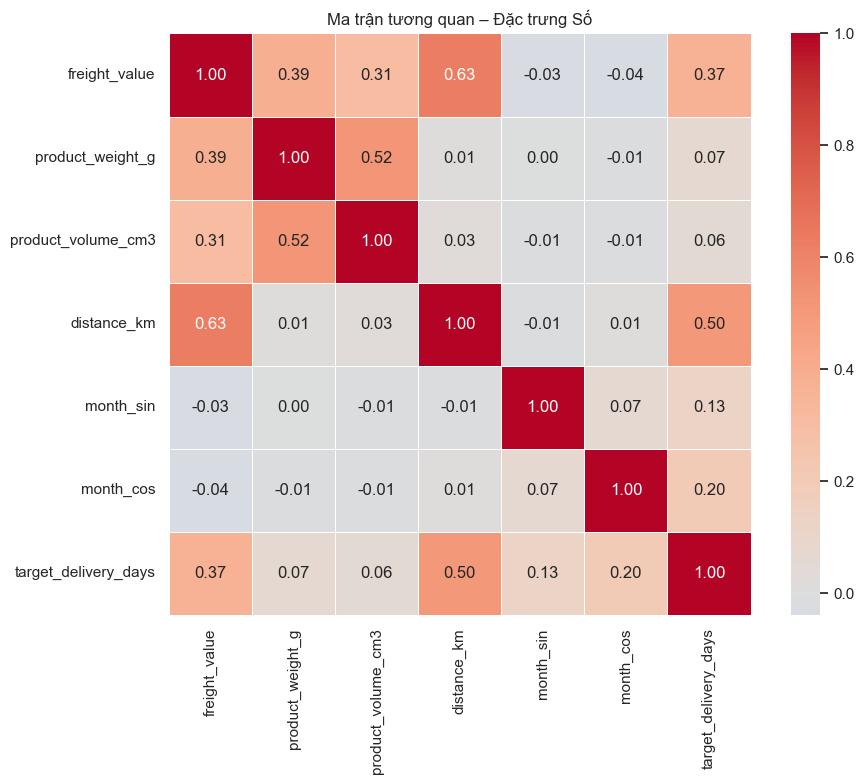

In [ ]:
df_corr = X_train_encoded.copy()
df_corr['target_delivery_days'] = y_train

numeric_cols_new = [
    'freight_value', 'product_weight_g', 'product_volume_cm3',
    'distance_km', 'month_sin', 'month_cos', 
    'target_delivery_days'
]

valid_cols = [c for c in numeric_cols_new if c in df_corr.columns]
corr_matrix = df_corr[valid_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('Ma trận tương quan – Đặc trưng Số')
plt.tight_layout()
plt.show()


### `Trích chọn + Chuẩn hóa đặc trưng`

In [ ]:
# y = df_ml['target_delivery_days'].values
# # 1. SCALE CÁC CỘT LIÊN TỤC BỊ LỆCH PHẢI 
# features_to_scale = [
#     'product_weight_g', 'product_length_cm', 'product_height_cm', 
#     'product_width_cm', 'distance_km'
# ]
# features_to_scale = [col for col in features_to_scale if col in df_ml.columns]
# df_ml_scaled = transform_and_scale_features(df_ml, features_to_scale)
# # 2. LỌC ĐẶC TRƯNG + ONE-HOT ENCODING
# numeric_features = ['price', 'freight_value',
#     'product_weight_g', 'product_length_cm', 'product_height_cm', 
#     'product_width_cm', 'distance_km']
# categorical_features = ['customer_state', 'seller_state', 'product_category_name_english', 'order_weekday', 'order_month']
# numeric_features   = [col for col in numeric_features   if col in df_ml_scaled.columns]
# categorical_features = [col for col in categorical_features if col in df_ml_scaled.columns]


# for col in ['order_weekday', 'order_month']:
#     if col in df_ml_scaled[col]:
#         df_ml_scaled[col] = df_ml_scaled.astype(str)


# df_features = df_ml_scaled[numeric_features + categorical_features].copy()
# df_encoded  = pd.get_dummies(df_features, columns=categorical_features, drop_first=True, dtype=int)
# feature_names = df_encoded.columns.tolist()
# X = df_encoded.values
# print(f"Tổng số features: {X.shape[1]}")
# # 3. CHIA TẬP 70 / 10 / 20
# X_temp, X_test, y_temp, y_test = train_test_split(
#     X, y, test_size=0.20, random_state=42
# )
# X_train, X_val, y_train, y_val = train_test_split(
#     X_temp, y_temp, test_size=0.125, random_state=42
# )
# total = X.shape[0]
# print(f"\nTrain : {X_train.shape[0]:>6} mẫu ({X_train.shape[0]/total*100:.0f}%)")
# print(f"Val   : {X_val.shape[0]:>6} mẫu ({X_val.shape[0]/total*100:.0f}%)")
# print(f"Test  : {X_test.shape[0]:>6} mẫu ({X_test.shape[0]/total*100:.0f}%)")


def preprocess_and_split_pipeline(df, target_col='target_delivery_days', test_size=0.20, val_size=0.10, random_state=42): 
    """
        Pipeline xử lý: Split -> Feature -> Feature Fit 
        Đảm bảo ko xảy ra Data Leakage
    """
    df_clean = df.copy()

    X = df_clean.drop(columns=[target_col])
    y = df_clean[target_col].values
    X_temp, X_test, y_temp, y_test = train_test_split(X,y,test_size=test_size, random_state=random_state)
    val_frac = val_size / (1.0-test_size)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_frac, random_state=random_state)

def engineer_features(data): 
    d_opt = data.copy()
    if set(['product_length_cm', 'product_height_cm', 'product_width_cm']).issubset(d_opt.columns): 
       d_opt['product_volume_cm3'] = d_opt['product_length_cm'] * d_opt['product_height_cm'] * d_opt['product_width_cm']
       d_opt.drop(columns=['product_length_cm', 'product_height_cm', 'product_width_cm'], inplace=True, errors='ignore') 
    
    cols_drop_geo = ['customer_state', 'seller_state']
    d_opt.drop(columns=[c for c in cols_drop_geo if c in d_opt.columns], inplace=True, errors='ignore')
    if 'order_weekday' in d_opt.columns:
            d_opt['is_weekend'] = d_opt['order_weekday'].apply(lambda x: 1 if x >= 5 else 0)
        
    if 'order_month' in d_opt.columns:
        d_opt['month_sin'] = np.sin(2 * np.pi * d_opt['order_month'] / 12)
        d_opt['month_cos'] = np.cos(2 * np.pi * d_opt['order_month'] / 12)
        
    d_opt.drop(columns=['order_weekday', 'order_month'], inplace=True, errors='ignore')
    return d_opt
#X_train = engineer_features(X_train)
#X_val   = engineer_features(X_val)
#X_test  = engineer_features(X_test)


In [ ]:
def preprocess_and_split_pipeline(df, target_col='target_delivery_days', test_size=0.20, val_size=0.10, random_state=42):
    """
    Pipeline xử lý chuẩn ML: Split trước -> Feature Engineering -> Feature Fit Transform
    Đảm bảo 100% No Data Leakage.
    """
    df_clean = df.copy()
    
    # -------------------------------------------------------------
    # BƯỚC 1: CHIA TẬP ĐỘC LẬP TRƯỚC TIÊN (NGĂN CHẶN LEAKAGE)
    # -------------------------------------------------------------
    X = df_clean.drop(columns=[target_col])
    y = df_clean[target_col].values
    
    # Chia theo test_size = 0.20
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    # Tính tỉ lệ thực tế của Validation set.
    val_frac = val_size / (1.0 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_frac, random_state=random_state)

    # -------------------------------------------------------------
    # BƯỚC 2: FEATURE ENGINEERING DÒNG (Không lệ thuộc chéo, áp dụng an toàn)
    # -------------------------------------------------------------
    def engineer_features(data):
        d_opt = data.copy()
        
        # 1. Thể tích (Duy trì thể tích - thay thế cho cân nặng)
        if set(['product_length_cm', 'product_height_cm', 'product_width_cm']).issubset(d_opt.columns):
            d_opt['product_volume_cm3'] = d_opt['product_length_cm'] * d_opt['product_height_cm'] * d_opt['product_width_cm']
            d_opt.drop(columns=['product_length_cm', 'product_height_cm', 'product_width_cm'], inplace=True, errors='ignore')
            
        # 2. Địa lý
        cols_drop_geo = ['customer_state', 'seller_state']
        d_opt.drop(columns=[c for c in cols_drop_geo if c in d_opt.columns], inplace=True, errors='ignore')
        
        # 3. Thời gian 
        # Đã lược bỏ logic tính is_weekend theo kết quả loại nhiễu.
        if 'order_month' in d_opt.columns:
            # Ép kiểu tháng về dạng Window Numeric chắc chắn để tính sin/cos
            month_num = pd.to_numeric(d_opt['order_month'], errors='coerce')
            d_opt['month_sin'] = np.sin(2 * np.pi * month_num / 12)
            d_opt['month_cos'] = np.cos(2 * np.pi * month_num / 12)
            
        d_opt.drop(columns=['order_weekday', 'order_month'], inplace=True, errors='ignore')
        
        return d_opt

    X_train = engineer_features(X_train)
    X_val   = engineer_features(X_val)
    X_test  = engineer_features(X_test)

    # -------------------------------------------------------------
    # BƯỚC 3: XỬ LÝ NHÓM (DỰA TRÊN THÔNG KÊ CHỈ TỪ TẬP TRAIN)
    # -------------------------------------------------------------
    if 'product_category_name_english' in X_train.columns:
        # TÌM TOP 10 DANH MỤC CHỈ TRÊN TẬP TRAIN
        top_10_cats = X_train['product_category_name_english'].value_counts().nlargest(10).index
        
        # Mapping Category (Áp dụng Top 10 của Train cho cả Val và Test)
        map_func = lambda x: x if x in top_10_cats else 'Other'
        X_train['product_category_name_english'] = X_train['product_category_name_english'].apply(map_func)
        X_val['product_category_name_english']   = X_val['product_category_name_english'].apply(map_func)
        X_test['product_category_name_english']  = X_test['product_category_name_english'].apply(map_func)

    # -------------------------------------------------------------
    # BƯỚC 4: SCALE & TRANFORM BẰNG COLUMN_TRANSFORMER
    # -------------------------------------------------------------
    # [CẬP NHẬT QUAN TRỌNG]: Đã xóa 'price', 'product_weight_g' và 'is_weekend'. 
    # Mọi biến không xuất hiện trong mảng này sẽ bị bộ Transform tự động gác bỏ.
    num_features = ['freight_value', 'product_volume_cm3', 'distance_km', 'month_sin', 'month_cos']
    num_features = [c for c in num_features if c in X_train.columns]
    
    cat_features = ['product_category_name_english']
    cat_features = [c for c in cat_features if c in X_train.columns]

    # Preprocessor xử lý Scale và OHE độc lập
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_features),
            ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_features)
        ],
        remainder='drop' # Tự động xóa các biến thừa đã bị loại từ EDA
    )
    
    # FIT CHỈ TRÊN TRAIN
    preprocessor.fit(X_train)
    
    # Lấy feature names mới nhất từ Preprocessor rẽ nhánh
    cat_encoder = preprocessor.named_transformers_['cat']
    feature_names = num_features + list(cat_encoder.get_feature_names_out(cat_features))
    
    # TRANSFORM TRÊN CẢ 3 TẬP 
    X_train_final = pd.DataFrame(preprocessor.transform(X_train), columns=feature_names, index=X_train.index)
    X_val_final   = pd.DataFrame(preprocessor.transform(X_val), columns=feature_names, index=X_val.index)
    X_test_final  = pd.DataFrame(preprocessor.transform(X_test), columns=feature_names, index=X_test.index)

    # In ra thông tin
    total = X.shape[0]
    print(f"Tổng số features của mô hình đầu vào: {X_train_final.shape[1]}")
    print(f"Train Set: {X_train_final.shape[0]:>6} mẫu ({X_train_final.shape[0]/total*100:.0f}%)")
    print(f"Val Set  : {X_val_final.shape[0]:>6} mẫu ({X_val_final.shape[0]/total*100:.0f}%)")
    print(f"Test Set : {X_test_final.shape[0]:>6} mẫu ({X_test_final.shape[0]/total*100:.0f}%)")
    
    return X_train_final, X_val_final, X_test_final, y_train, y_val, y_test, preprocessor

# ==============================================================
# GỌI HÀM THỰC THI
# ==============================================================
#X_train, X_val, X_test, y_train, y_val, y_test, preprocessor = preprocess_and_split_pipeline(df_ml, test_size=0.20, val_size=0.10)


### Bảng tổng hợp đặc trưng đầu vào (Sau Tối Ưu Hóa & Lựa Chọn Cuối Cùng)

| Đặc trưng | Loại | Mô tả | Chi tiết Xử lý |
|-----------|------|-------|-------|
| `freight_value` | Liên tục | Phí vận tải (BRL) - Đại diện gián tiếp cho bài toán Logistics. | Standardization |
| `product_volume_cm3` | Liên tục | Thể tích của sản phẩm ($Dài \times Rộng \times Cao$). Giữ lại làm đại diện cho sự cồng kềnh. | Standardization |
| `distance_km` | Liên tục | Khoảng cách Haversine từ kho người bán đến nhà người mua (km). | Standardization |
| `product_category_name_english` | Phân loại | Danh mục sản phẩm bán hàng (Tiếng Anh). | Lọc Top 10 + "Other" $\rightarrow$ One-Hot Encoding |
| `month_sin`, `month_cos` | Liên tục | Khai thác tính Mùa Vụ. Mã hóa hàm Lượng Giác giúp bảo toàn tính chu kỳ thời gian (Tháng 12 nối liền về Tháng 1). | Trực tiếp (Pass-through) |

**Biến mục tiêu:** `target_delivery_days` — Số ngày từ lúc xác nhận đơn hàng đến lúc nhận hàng thực tế (đơn vị: ngày).

--- 
**Các đặc trưng đã được phân tích và LƯỢC BỎ (Dựa trên EDA và Tránh Đa Cộng Tuyến):**
- **Trọng lượng & Kích thước thô (`product_weight_g`, `length_cm`, `width_cm`, `height_cm`):** Kích thước 3D đã được quy đổi thành cấu trúc Thể tích. Cột cân nặng (`product_weight_g`) bị lược bỏ triệt để vì có Đa cộng tuyến (Multicollinearity) quá cao ($r = 0.72$) với thể tích, dễ làm sai lệch trọng số biến trong mô hình Hồi quy.
- **Biến nhiễu phi tuyến tính (`price`, `is_weekend`):** Có hệ số tương quan tuyến tính với Target cực kỳ thấp ($r = 0.04$ và $r = 0.01$). Về mặt Logic: *Giá trị món đồ đắt/rẻ* không làm tài xế giao nhanh hơn; và ảnh hưởng *chênh lệch 1-2 ngày cuối tuần* đã bị pha loãng hoàn toàn vào chu kỳ Logistics kéo dài 10-15 ngày.
- **Nhóm Địa lý danh nghĩa (`customer_state`, `seller_state`):** Chứa thông tin chồng chéo nhưng lại sinh ra quá nhiều chiều dữ liệu thưa (số lượng Sparse Data cao) nếu dùng OHE. Sự ảnh hưởng của địa lý đã được nội suy xuất sắc qua quãng đường vật lý `distance_km`.
- **Nhóm thời gian gốc (`order_month`, `order_weekday`):** Đã xóa bỏ tận gốc để không sinh ra bẫy biến giả r


## **Trực quan hóa các đặc trưng sau khi xử lí**

### a. Heatmap tương quan

### `Nhận xét:`

- Triệt tiêu Đa cộng tuyến (Multicollinearity): Đã loại bỏ product_weight_g (tương quan 0.72 với thể tích) và các chiều vật lý mộc để giữ lại duy nhất đại diện không gian là product_volume_cm3.

- Lọc nhiễu & Tránh ma trận thưa (Sparsity): Xóa bỏ các đặc trưng có tín hiệu yếu (price, is_weekend) và nhóm địa lý danh nghĩa (customer_state, seller_state) do đã được nội suy hoàn hảo bởi biến liên tục distance_km. Danh mục sản phẩm được gom nhóm (Top 10 + Other) để tránh tạo ra hàng chục cột OHE vô giá trị.

- Bảo toàn Tín hiệu Lõi (Core Signals): Tập trung vào cấu trúc Logistics cốt lõi gồm: Khoảng cách (distance_km), Cước phí (freight_value), Độ cồng kềnh (volume), Chu kỳ mùa vụ (month_sin, month_cos) và Loại hàng hóa chính.

### `Lưu ra file CSV`

In [ ]:
#process_path = os.path.join(path,"processed")
#os.makedirs(process_path, exist_ok=True)

# Chỉ việc sử dụng trực tiếp X_train, X_val, X_test (vì nó TRƯỚC ĐÓ ĐÃ LÀ DATAFRAME rồi)
#df_train = X_train.copy()
#df_train['target_delivery_days'] = y_train 

#df_val = X_val.copy()
#df_val['target_delivery_days'] = y_val

#df_test = X_test.copy()
#df_test['target_delivery_days'] = y_test

# Lưu vào csv 
#df_train.to_csv(os.path.join(process_path, "train.csv"), index=False)
#df_val.to_csv(os.path.join(process_path, "val.csv"), index=False)
#df_test.to_csv(os.path.join(process_path, "test.csv"), index=False)

#print(f"Số lượng đặc trưng Train thực tế: {df_train.shape[1]} cột")
#print(f"Đã lưu thành công vào file csv!")
